# Sequence models on irregular panels: what they do with a gap

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/panel_sequence_models.ipynb)

Companion notebook to part 8 of the series on predictive modelling with panel data.

Part 6 gave the random effect a clock: an exponential kernel over observation time, whose
conditional mean shrinks the last observation by `exp(-gap / range)` and whose conditional variance
grows toward the marginal one as the gap opens. Part 7 asked who arrives. This notebook asks what
the sequence architectures do with the same gap.

Two things get measured. An identity: the decay these models use to give a gap a meaning is the
conditional mean of part 6's kernel, exactly, with the range fitted by gradient descent instead of
by likelihood. And a consequence that is not the obvious one. Asked for an interval, GRU-D's
Gaussian head does widen it as the gap opens, so the decay reaches the second moment as well as the
first. What it fails at is the level: coverage falls from the first gap bin to the last on every seed
while every closed-form arm holds its nominal level across the same bins.

The comparison runs on a panel whose truth contains something part 6's kernel cannot express, a
nonlinear functional of the covariate path, so neither route is correct by construction. The same
panel is generated with that term off and on, sharing its random numbers, which makes every
contrast paired.

In [1]:
import importlib.util
if importlib.util.find_spec("lightgbm") is None or importlib.util.find_spec("gpboost") is None:
    !pip install -q lightgbm==4.7.0 gpboost==1.7.4 matplotlib
if importlib.util.find_spec("torch") is None:
    !pip install -q torch

## Why torch is not imported in this notebook

`lightgbm` and `torch` each ship their own copy of the OpenMP runtime, and on macOS the one that
initialises first owns the process: importing `torch` before the first `lightgbm` call kills the
interpreter with no traceback, and `KMP_DUPLICATE_LIB_OK=TRUE` only downgrades that to a documented
risk of silently wrong results. Linux wheels usually share one `libgomp`, so the clash may not
arise there, but nothing below depends on which platform you are on.

The sequence arm therefore runs in a separate process, written out by the notebook and called with
`sys.executable`. That costs one `np.savez` and is safe everywhere. Do not tidy the torch import
into the cell below.

In [2]:
import sys, time, warnings
import numpy as np, pandas as pd, lightgbm as lgb, gpboost as gpb
from scipy.stats import norm
from scipy.optimize import minimize, brentq

warnings.filterwarnings("ignore")
pd.set_option("display.width", 250, "display.max_columns", 60)
print("lightgbm", lgb.__version__, "| gpboost", gpb.__version__)

lightgbm 4.7.0 | gpboost 1.7.4


## The panel

`NG` units are observed over a window of `T_WIN`, and `T_CUT` splits every unit by time: rows
before it are training rows, rows after it are the deployment target. Arrival is an ignorable
Poisson process at rate `LAM`, drawn by thinning a dense grid of step `H`, which leaves the latent
panel available to the oracle.

The outcome has three parts that behave differently under a gap:

    y = g(x) + c * z(t) + u(t) + noise

- `g(x)` is memoryless in the current covariates, which a booster fits directly.
- `u(t)` is part 6's Ornstein-Uhlenbeck unit effect, covariance `SU**2 * exp(-|t - t'| / RHO)`.
  This is the part an exponential kernel is exactly right about.
- `z(t)` is an exponentially weighted average of a nonlinear function of the covariate *path*,
  `z(t) = integral of KAPPA * exp(-KAPPA * (t - s)) * beta(x(s)) ds`, computed exactly on the dense
  grid by its own recursion. No covariance over observation times can express it, because it is not
  a random effect: it is a deterministic functional of a path the model sees only at the sampled
  points. `c` switches it off and on.

The covariates are themselves OU paths, so the path has something to remember.

In [3]:
NG, T_WIN, T_CUT, LAM, H = 120, 12.0, 8.0, 2.0, 0.05
SU, SE, RHO = 1.0, 0.5, 4.0     # sd of the unit effect, sd of the noise, range of the unit effect
RHO_X, KAPPA = 1.0, 1.0         # range of the covariate paths, decay rate of the path memory
CVAL = 2.0                      # weight on the path memory when it is switched on
RATES = (0.25, 1.0, 4.0)        # the rates a modeller guesses, one of them right
SIZES, CS, NSEED = (120, 480), (0.0, CVAL), 5
CLAB = {0.0: "off", CVAL: "on"}                 # how each value of c is named in every table
HOLD = 0.25                                     # share of units the sequence arm validates on
M, K_FOLDS = 300, 4
PARN = ["s2", "var_u", "range"]                 # the covariance parameters, in fit_cov's order
GRID = np.arange(H, T_WIN + 1e-9, H)
NT = len(GRID)
FEAT = ["x1", "x2"]
Z90 = norm.ppf(0.95)
BIG = SIZES[-1]                 # the size the later cells draw on
# num_threads is pinned: these fits are a few thousand rows on a handful of features, where the
# threading overhead is the whole cost, and one thread also makes the output independent of the
# machine it runs on
BASE = {"objective": "regression_l2", "learning_rate": 0.05, "num_leaves": 31,
        "min_data_in_leaf": 20, "num_threads": 1, "verbose": -1}


def rmse(y, p):
    return float(np.sqrt(np.mean((y - p)**2)))


def band(s):
    return f"{s.mean():.3f} [{s.min():.3f}, {s.max():.3f}]"


# n independent Ornstein-Uhlenbeck paths on GRID, exactly, by the AR(1) recursion
def ou_paths(rng, n, var, rho):
    phi = np.exp(-H/rho)
    z = np.empty((n, NT))
    z[:, 0] = rng.normal(0, np.sqrt(var), n)
    e = rng.normal(0, np.sqrt(var*(1 - phi**2)), (n, NT))
    for j in range(1, NT):
        z[:, j] = phi*z[:, j-1] + e[:, j]
    return z


def beta(x1, x2):               # the nonlinearity the path memory averages
    return np.tanh(1.5*x1) + 0.7*x2**2 - 0.7


def gfun(x1, x2):               # the memoryless part of the mean
    return 1.2*np.sin(2.0*x1) + 0.8*x1*x2


# the path memory, exactly: beta is constant on each grid interval, so the integral has a recursion
def ewma_grid(b, kappa):
    a = np.exp(-kappa*H)
    z = np.zeros_like(b)
    for j in range(1, b.shape[1]):
        z[:, j] = a*z[:, j-1] + (1 - a)*b[:, j-1]
    return z

In [4]:
# every draw is made in the same order whatever c is, so switching the path memory on and off
# leaves the paths, the arrival times and the noise untouched, and every contrast below is paired
# positional index of the last training row of this row's unit, strictly before it, NaN if there
# is none. Every "gap" in the notebook and the GRU's lag channel are read off this one expression.
def last_train(d):
    i = pd.Series(np.arange(len(d)), dtype=float).where(d.t.values <= T_CUT)
    return i.groupby(d.unit.values).shift().groupby(d.unit.values).ffill().values


# noise, thinning and the frame, shared by every panel in the notebook so that the only thing
# a variant changes is the draw it was written to change
def assemble(rng, X1, X2, Mm, U, ng):
    E = rng.normal(0, SE, (ng, NT))
    i, j = np.nonzero(rng.uniform(size=(ng, NT)) < LAM*H)
    d = pd.DataFrame({"unit": i, "t": GRID[j], "x1": X1[i, j], "x2": X2[i, j],
                      "m": Mm[i, j], "y": (Mm + U + E)[i, j]}
                     ).sort_values(["unit", "t"], ignore_index=True)
    li, t = last_train(d), d.t.values
    has = ~np.isnan(li)
    # the gap to the unit's last training row, for every row: at a target row that is the
    # forecast horizon, at a training row the step from the previous one. NaN where the unit
    # has no earlier training row at all.
    d["gap"] = np.where(has, t - t[np.nan_to_num(li).astype(int)], np.nan)
    return d


def panel(seed, c, ng=NG):
    rng = np.random.default_rng(seed)
    X1, X2 = ou_paths(rng, ng, 1.0, RHO_X), ou_paths(rng, ng, 1.0, RHO_X)
    U = ou_paths(rng, ng, SU**2, RHO)
    Zc = c*ewma_grid(beta(X1, X2), KAPPA)
    Mm = gfun(X1, X2) + Zc
    return assemble(rng, X1, X2, Mm, U, ng), (Mm - Zc, Zc)


# the same exponential average, but over a unit's own observed rows rather than the latent path,
# and over whatever columns it is handed. This is what a modeller can actually build, and it is
# causal at every row: the state entering row k is built from rows strictly before it.
def ewma_rows(d, rates, cols):
    t, u, k = d.t.values, d.unit.values, cols.shape[1]
    out = np.zeros((len(d), len(rates)*k))
    st, prev_c = np.zeros((len(rates), k)), np.zeros(k)
    prev_u, prev_t = -1, 0.0
    for i in range(len(d)):
        if u[i] != prev_u:
            prev_u, st[:] = u[i], 0.0
        else:
            a = np.exp(-np.asarray(rates)*(t[i] - prev_t))[:, None]
            st = a*st + (1 - a)*prev_c
        out[i] = st.reshape(-1)
        prev_t, prev_c = t[i], cols[i]
    return out


def truth_col(d):               # the nonlinearity the truth averages, handed to the model
    return beta(d.x1.values, d.x2.values)[:, None]


def basis_cols(d):              # a generic quadratic basis, for a modeller who does not know it
    x1, x2 = d.x1.values, d.x2.values
    return np.column_stack([x1, x2, x1**2, x2**2, x1*x2])


# adds the guessed columns to the frame it is handed and returns their names. Hand it a fresh
# frame: a second call with different rates would otherwise leave the first call's columns behind.
def add_ewma(d, rates=RATES, cols=truth_col):
    c = cols(d)
    names = [f"w{i}" for i in range(len(rates)*c.shape[1])]
    d[names] = ewma_rows(d, rates, c)
    return names

In [5]:
d, (G, CZ) = panel(0, CVAL)
n = d.groupby("unit").size()
print(f"seed 0: {len(d)} rows, {int(n.median())} per unit median, "
      f"{(d.t <= T_CUT).sum()} before the cut and {(d.t > T_CUT).sum()} after")
print(f"  variance of the memoryless mean {G.var():.3f}, of the path memory {CZ.var():.3f}, of "
      f"the two together {(G + CZ).var():.3f}, so the path memory is "
      f"{CZ.var()/(G + CZ).var():.0%} of the mean's variance")
print(f"  variance of the unit effect {SU**2:.2f}, of the noise {SE**2:.2f}")
g = d.gap.values[d.t > T_CUT]
print(f"  gap to the last training row, after the cut: quartiles "
      f"{np.round(np.quantile(g, [0.25, 0.5, 0.75]), 2)}, longest {g.max():.1f}")

seed 0: 2875 rows, 24 per unit median, 1879 before the cut and 996 after
  variance of the memoryless mean 1.379, of the path memory 2.289, of the two together 4.289, so the path memory is 53% of the mean's variance
  variance of the unit effect 1.00, of the noise 0.25
  gap to the last training row, after the cut: quartiles [1.54 2.55 3.5 ], longest 6.2


### One set of gap bins, equal-count

Every table below splits the target rows by the gap. Bins of equal width on this distribution put
almost nothing in the last one, so its coverage would be a handful of rows. The bins are therefore
quantiles of the target-row gaps over the five large panels, fixed once and used everywhere,
including on the training rows, whose gaps are shorter and so fill the first bins.

In [6]:
def target_gaps(p):             # the gaps the bins are cut on: rows after the cut, with a history
    return p.gap.values[(p.t.values > T_CUT) & ~np.isnan(p.gap.values)]


PAN0 = [panel(s, 0.0, ng=BIG)[0] for s in range(NSEED)]
TG = np.concatenate([target_gaps(p) for p in PAN0])
GAPB = np.r_[0.0, np.quantile(TG, np.linspace(0, 1, 7))[1:-1], np.inf]
GAPL = ([f"<{GAPB[1]:.2f}"] + [f"{a:.2f}-{b:.2f}" for a, b in zip(GAPB[1:-2], GAPB[2:-1])]
        + [f">{GAPB[-2]:.2f}"])
WCOL, CCOL = [f"w {b}" for b in GAPL], [f"cov {b}" for b in GAPL]
one = target_gaps(PAN0[0])
print(f"target-row gaps, {BIG} units: {len(TG)} rows over {NSEED} seeds, seed 0 alone {len(one)}")
print("  seed 0, four equal-width bins:", pd.Series(pd.cut(one, 4)).value_counts().sort_index().tolist())
print("  seed 0, four equal-count bins:", pd.Series(pd.qcut(one, 4)).value_counts().sort_index().tolist())
print("  the six bins used below, over all seeds:",
      dict(zip(GAPL, pd.Series(pd.cut(TG, GAPB, labels=GAPL)).value_counts().sort_index().tolist())))

target-row gaps, 480 units: 18971 rows over 5 seeds, seed 0 alone 3806
  seed 0, four equal-width bins: [1257, 1610, 896, 43]
  seed 0, four equal-count bins: [952, 958, 957, 939]
  the six bins used below, over all seeds: {'<1.10': 3222, '1.10-1.80': 3216, '1.80-2.45': 3048, '2.45-3.15': 3287, '3.15-3.80': 3086, '>3.80': 3112}


## The identity

Several architectures give a gap a meaning through a decay, though not all of them do: mTAND
attends over an embedded time axis and a neural CDE integrates a learned vector field, and neither
reduces to what follows. GRU-D's input decay is

    gamma = exp(-max(0, W * delta + b));   xhat = gamma * x_last + (1 - gamma) * xbar

and part 6's kernel says the conditional mean of an Ornstein-Uhlenbeck process at a distance
`delta` past the last observation is

    E[u(t + delta) | u(t)] = mu + exp(-delta / rho) * (u(t) - mu)

These are the same expression. With `W = 1 / rho` and `b = 0` the gate is the kernel and the
empirical mean `xbar` is the process mean. The decay is not an alternative to a covariance
function, it is one, restricted to the exponential family and fitted by gradient descent rather than
by likelihood. Rubanova et al. (2019, section 3.1) make a related point from the other
direction, citing Mozer et al. (2017): a hidden state decaying to zero solves a linear ODE. That is
not quite this identity, which relaxes toward a nonzero mean, but it is the same observation about
what a decay is. The continuous recurrent unit runs a
continuous-discrete Kalman filter over a linear latent SDE, which with a scalar latent state is
`corCAR1`; with the vector state it actually uses, it is a linear system whose marginals are still
Gaussian but no longer that one. Latent ODEs relax along a learned vector field, so nothing there
reduces to an exponential.

The same caveat applies to GRU-D's own hidden decay, and it is worth stating before the arm is
fitted. Equation 6 decays a `HID`-dimensional state through a full matrix, so it is a sum of that
many exponentials rather than one, and only the input decay of equations 4 and 5 is the scalar the
identity above is about. A later cell reports how often that scalar was switched off, which decides
which of the two was carrying the gap.

The half of that conditional law a gate has no output for is

    Var[u(t + delta) | u(t)] = sigma_u**2 * (1 - exp(-2 * delta / rho))

A gate has no output for that, but a network carrying the gate has a head, and whether the head
recovers it is measured later rather than asserted here. This cell fixes only what the right answer
is. One detail to keep in view: `max(0, .)` is flat below zero, so a fitted `W` on the wrong side of
it leaves the gate at exactly 1 and the decay switched off. A later cell reports where `W` landed.

In [7]:
DEL = np.array([0.1, 0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0])
X_LAST, XBAR = 1.7, 0.4         # a unit's last observed value, and the process mean it relaxes to
W, B = 1.0/RHO, 0.0             # the gate weights that make GRU-D part 6's kernel

gate = np.exp(-np.maximum(0.0, W*DEL + B))                 # GRU-D's gate, verbatim
grud = gate*X_LAST + (1 - gate)*XBAR                       # and what it imputes
kern = XBAR + np.exp(-DEL/RHO)*(X_LAST - XBAR)             # part 6's conditional mean
print(f"the two expressions over these gaps: largest difference "
      f"{np.abs(grud - kern).max():.1e}")
print()
# the sd of a new observation under the same law: sqrt(SU**2 (1 - exp(-2 d / RHO)) + SE**2)
ou_sd = np.sqrt(SU**2*(1 - np.exp(-2*DEL/RHO)) + SE**2)
print("  gap                     " + "".join(f"{v:7.2f}" for v in DEL))
print("  weight on the last row  " + "".join(f"{v:7.3f}" for v in gate))
print("  imputed value, GRU-D    " + "".join(f"{v:7.3f}" for v in grud))
print("  imputed value, part 6   " + "".join(f"{v:7.3f}" for v in kern))
print("  sd of a new observation " + "".join(f"{v:7.3f}" for v in ou_sd))
print()
print(f"over these gaps the sd a correct interval needs travels a factor of "
      f"{ou_sd[-1]/ou_sd[0]:.1f} from end to end. What that costs is priced further down, over the "
      f"gaps this panel\nactually produces rather than over a hand-picked grid of them.")

the two expressions over these gaps: largest difference 2.2e-16

  gap                        0.10   0.25   0.50   1.00   2.00   3.00   4.00   6.00
  weight on the last row    0.975  0.939  0.882  0.779  0.607  0.472  0.368  0.223
  imputed value, GRU-D      1.668  1.621  1.547  1.412  1.188  1.014  0.878  0.690
  imputed value, part 6     1.668  1.621  1.547  1.412  1.188  1.014  0.878  0.690
  sd of a new observation   0.547  0.606  0.686  0.802  0.939  1.013  1.056  1.096

over these gaps the sd a correct interval needs travels a factor of 2.0 from end to end. What that costs is priced further down, over the gaps this panel
actually produces rather than over a hand-picked grid of them.


## The arms

Seven ways to spend, all fitted on the same rows and all scored on the rows after the cut, all
reporting a 90% interval. They are not all given the same information, and the exception is stated
where it arises.

- `pooled`: LightGBM on the current covariates. Its interval is one number, the out-of-fold
  residual variance.
- `+ ewma`: the same booster with three extra columns, exponential averages of `beta(x)` over the
  unit's own observed rows at rates `RATES`. This is the path memory guessed by hand, and it is the
  arm with an unfair advantage: it is handed `beta` itself, the nonlinearity the truth averages, and
  one of its three rates is the true one. Two later cells take both of those away.
- `+ kernel`: part 6's two stages without the library. Pooled LightGBM for the mean, out-of-fold
  residuals by unit, an exponential covariance fitted to those residuals by maximum likelihood,
  then the conditional mean and variance in closed form.
- `+ both`: the guessed columns, and the kernel on their residuals.
- `+ both, joint`: the same columns and the same exponential kernel, fitted jointly by GPBoost
  rather than in two stages, so the covariance and the trees are estimated together.
- `+ GRU-D`: GRU-D as published, Che et al. (2018) equations 4 to 6, with one departure. Its input
  decay acts on the residual at the unit's last training row, its hidden state decays by a full
  matrix over the step and the gap, the mask goes into the cell, and a Gaussian
  mean-and-log-variance head reads the state. The departure is equation 4's observed branch, which
  would hand a row its own outcome here, since the variable being imputed is the target itself. It
  runs in the separate process explained above.
- `oracle`: the true mean and the true covariance, conditioned on the same rows. Unreachable by
  construction, since `z` is a functional of a path nobody observes, and the only honest reference
  for how much of the gap is closable at all.

Every table splits the target rows by the gap to the unit's last training row, using one fixed set
of bins, because a number averaged over that gap is the number no one is served.

In [8]:
def folds(tr, seed):            # by unit, so a unit's own rows cannot fit its own effect
    u = np.unique(tr.unit.values)
    return np.random.default_rng(seed).integers(0, K_FOLDS, len(u))[
        np.searchsorted(u, tr.unit.values)]


def pooled(tr, feats, m=M):
    return lgb.train(BASE, lgb.Dataset(tr[feats].values, tr.y.values), num_boost_round=m)


def oof(tr, seed, feats):
    fold = folds(tr, seed)
    p = np.empty(len(tr))
    for k in range(K_FOLDS):
        p[fold == k] = pooled(tr[fold != k], feats).predict(tr[fold == k][feats].values)
    return tr.y.values - p


def cov_pair(a, b, par):
    _, vu, rho = par
    return vu*np.exp(-np.abs(a[:, None] - b[None, :])/rho)


# the residual likelihood, unit by unit. The pairwise distances are fixed for the whole
# optimisation, so they are built once by the caller.
def cov_nll(z, groups):
    s2, vu, rho = np.exp(z)
    tot = 0.0
    for D, r, n in groups:
        C = vu*np.exp(-D/rho)
        C.flat[::n + 1] += s2
        L = np.linalg.cholesky(C)
        a = np.linalg.solve(L, r)
        tot += 2*np.log(np.diag(L)).sum() + a @ a
    return tot


def fit_cov(tr, r):
    groups = []
    for i in tr.groupby("unit").indices.values():
        t = tr.t.values[i]
        groups.append((np.abs(t[:, None] - t[None, :]), r[i], len(i)))
    z = minimize(cov_nll, np.log([r.var()/3, 2*r.var()/3, T_WIN/4]),   # not RHO
                 args=(groups,), method="Nelder-Mead",
                 options={"xatol": 1e-3, "fatol": 1e-3, "maxiter": 4000}).x
    return np.exp(z)


# the conditional mean and variance at the target rows, per unit, given that unit's residuals
def krige(tr, te, r, par, fx, cov=cov_pair):
    idx = tr.groupby("unit").indices
    s2, vu = par[0], par[1]
    mu, var = np.array(fx, float), np.full(len(te), vu + s2)
    for ti in te.groupby("unit").indices.values():
        o = idx.get(te.unit.values[ti[0]])
        if o is None:                               # a unit with no training row: the prior
            continue
        a, rr = tr.t.values[o], r[o]
        C = cov(a, a, par) + s2*np.eye(len(a))
        k = cov(te.t.values[ti], a, par)
        sol = np.linalg.solve(C, np.c_[k.T, rr])
        mu[ti] += sol[:, -1] @ k.T
        var[ti] -= np.einsum("ij,ij->i", k, sol[:, :-1].T)
    return mu, var


def oracle(tr, te):
    return krige(tr, te, tr.y.values - tr.m.values, np.array([SE**2, SU**2, RHO]), te.m.values)


def gbin(g):                    # the one set of gap bins every table in the notebook uses
    return pd.cut(g, GAPB, labels=GAPL)


def score(name, te, mu, var):
    sd = np.broadcast_to(np.sqrt(np.maximum(var, 1e-12)), (len(te),))
    hit, w = np.abs(te.y.values - mu) < Z90*sd, 2*Z90*sd
    g = gbin(te.gap.values)
    o = {"arm": name, "rmse": rmse(te.y.values, mu), "cov90": float(hit.mean()),
         "width": float(w.mean())}
    for tag, v in (("w", w), ("cov", hit)):
        for k, m in pd.Series(v).groupby(g, observed=True).mean().items():
            o[f"{tag} {k}"] = float(m)
    return o

### The sequences GRU-D reads

One padded sequence per unit, its rows in time order, six channels. GRU-D is written for a variable
that is sometimes missing, so the encoding has to say which variable that is here: it is the
residual, which stops being observed at the cut. Hence the channels are the two covariates, the
residual at the unit's last *training* row, a mask saying whether there was one, the step to the
previous row, and `delta`, the time since that last training row. `delta` is what the input decay
acts on, and it is the quantity the paper's `d` denotes.

The target is the residual from the pooled booster, the same quantity the kernel arm models, so the
two arms are asked the same question. The loss is masked to training rows, and the `lag` channel is
read at training rows only, so no row is given its own outcome or a later one. The covariates,
`step` and `delta` at a target row are available at prediction time and are passed through.

In [9]:
def sequences(d, resid):
    li = last_train(d)
    has = ~np.isnan(li)
    lag = np.where(has, resid[np.nan_to_num(li).astype(int)], 0.0)
    delta = np.nan_to_num(d.gap.values)            # what the input decay acts on
    tr = d.t.values <= T_CUT
    idx = [v for _, v in sorted(d.groupby("unit").indices.items())]
    nb, L = len(idx), max(len(v) for v in idx)
    X = np.zeros((nb, L, 6), np.float32)
    Y = np.zeros((nb, L), np.float32)
    mtr, pos = np.zeros((nb, L), bool), np.full((nb, L), -1)
    for b, p in enumerate(idx):
        tt, n = d.t.values[p], len(p)
        X[b, :n] = np.column_stack([d.x1.values[p], d.x2.values[p], lag[p], has[p],
                                    np.diff(tt, prepend=tt[0]), delta[p]])
        Y[b, :n] = resid[p]
        mtr[b, :n], pos[b, :n] = tr[p], p
    return {"X": X, "Y": Y, "mtr": mtr}, pos

## Stage one: everything that is not torch

Twenty panels, two sizes by the path memory off and on by five seeds, each scored on the four
closed-form arms and the oracle. The sequences go to disk for the next cell.

In [10]:
GPB_BASE = {k: v for k, v in BASE.items() if k != "objective"}   # gpboost sets its own


# the covariance and the trees estimated together, the alternative to the two stages above
def joint(tr, te, feats):
    gp = gpb.GPModel(gp_coords=tr[["t"]].values, cluster_ids=tr.unit.values,
                     cov_function="exponential", likelihood="gaussian")
    bst = gpb.train(params=GPB_BASE, train_set=gpb.Dataset(tr[feats].values, tr.y.values),
                    gp_model=gp, num_boost_round=M)
    p = bst.predict(data=te[feats].values, gp_coords_pred=te[["t"]].values,
                    cluster_ids_pred=te.unit.values, predict_var=True)
    return (p["response_mean"], np.maximum(p["response_var"], 0.0),
            np.asarray(gp.get_cov_pars(), float).ravel())


def stage1(seed, c, ng):
    d, _ = panel(seed, c, ng=ng)
    WF = add_ewma(d)
    m = d.t.values > T_CUT
    tr, te = d[~m], d[m]
    fx, fe = (pooled(tr, f).predict(d[f].values) for f in (FEAT, FEAT + WF))
    r, re = d.y.values - fx, d.y.values - fe
    r[~m], re[~m] = oof(tr, seed, FEAT), oof(tr, seed, FEAT + WF)
    par, pare = fit_cov(tr, r[~m]), fit_cov(tr, re[~m])
    omu, ovar = oracle(tr, te)
    kern, both = krige(tr, te, r[~m], par, fx[m]), krige(tr, te, re[~m], pare, fe[m])
    out = [score("pooled", te, fx[m], r[~m].var()),
           score("+ ewma", te, fe[m], re[~m].var()),
           score("+ kernel", te, *kern),
           score("+ both", te, *both),
           score("oracle", te, omu, ovar)]
    jnt, parj = (None, None), np.full(len(PARN), np.nan)
    if ng == BIG:                               # the size every comparison of the two reads
        *jnt, parj = joint(tr, te, FEAT + WF)
        out.append(score("+ both, joint", te, *jnt))
    cov = dict(zip(PARN, par), **dict(zip([f"{n} ewma" for n in PARN], pare)),
               **dict(zip([f"{n} joint" for n in PARN], parj)))
    wire, pos = sequences(d, r)
    return out, cov, wire, {"te": te, "fx": fx[m], "pos": pos, "resid": r, "is_tr": ~m,
                            "gap": d.gap.values, "oracle_sd": np.sqrt(ovar),
                            "kern": kern, "both": both, "joint": tuple(jnt)}


t0 = time.time()
rows, covs, packs, keep = [], [], {}, {}
for ng in SIZES:
    for c in CS:
        for s in range(NSEED):
            out, cov, wire, aux = stage1(s, c, ng)
            k, base = f"{ng}_{c}_{s}", {"seed": s, "c": c, "ng": ng}
            rows += [dict(o, **base) for o in out]
            covs.append(dict(cov, **base))
            # the quarter of units the arm validates on. Drawn here so that one side owns it
            # and the mask, not a seed, is what crosses.
            hold = np.random.default_rng(s).random(aux["pos"].shape[0]) < HOLD
            packs.update({f"{nm}_{k}": v for nm, v in wire.items()})
            packs[f"hold_{k}"] = hold
            keep[k] = dict(aux, base=base, hold=hold)
np.savez("seq8.npz", **packs)
R, CV = pd.DataFrame(rows), pd.DataFrame(covs)
print(f"stage one: {time.time() - t0:.0f}s, sequences in seq8.npz")

stage one: 59s, sequences in seq8.npz


### What the covariance fit reports

Before any of the arms are compared, one number is worth reading on its own. The two-stage route
estimates the covariance from residuals of a mean function fitted without knowing about it, so
whatever the mean function misses arrives in the covariance. With the path memory switched on, what
it misses is a term that persists within a unit and decays on its own clock.

In [11]:
print(f"true noise variance {SE**2:.2f}, unit-effect variance {SU**2:.2f}, range {RHO:.1f}")
print(CV.groupby(["ng", "c"])[PARN + [f"{n} ewma" for n in PARN]].mean().round(3).to_string())
print()
q = CV[CV.ng == BIG].groupby("c")[["var_u", "range", "var_u ewma", "range ewma"]].mean()
print(f"switching the path memory on multiplies the fitted unit-effect variance by "
      f"{q.loc[CVAL, 'var_u']/q.loc[0.0, 'var_u']:.2f} and the fitted range by "
      f"{q.loc[CVAL, 'range']/q.loc[0.0, 'range']:.2f}, at {BIG} units")
print(f"  with the guessed columns in the mean, the same two factors are "
      f"{q.loc[CVAL, 'var_u ewma']/q.loc[0.0, 'var_u ewma']:.2f} and "
      f"{q.loc[CVAL, 'range ewma']/q.loc[0.0, 'range ewma']:.2f}")
print("the noise term absorbs the booster's own error on the mean, which is why it sits above")
print(f"{SE**2:.2f} everywhere and falls as the panel grows.")

true noise variance 0.25, unit-effect variance 1.00, range 4.0
            s2  var_u  range  s2 ewma  var_u ewma  range ewma
ng  c                                                        
120 0.0  0.503  1.148  4.111    0.484       1.268       3.394
    2.0  0.742  2.325  1.690    0.536       1.942       2.145
480 0.0  0.338  1.012  3.782    0.335       1.037       3.482
    2.0  0.467  2.301  1.581    0.352       1.656       2.164

switching the path memory on multiplies the fitted unit-effect variance by 2.27 and the fitted range by 0.42, at 480 units
  with the guessed columns in the mean, the same two factors are 1.60 and 0.62
the noise term absorbs the booster's own error on the mean, which is why it sits above
0.25 everywhere and falls as the panel grows.


### The kernel's interval stops growing

The kernel's predictive variance at a gap is the unit-effect variance the unit's own rows no longer
explain, plus the noise. As the gap grows the correlation with those rows goes to zero, so the
interval does not widen without limit: it settles at the marginal sd, `sqrt(var_u + s2)`. The curve
below is one unit's, the one with the median number of training rows, conditioned on those rows,
under the true covariance and under the median fitted one.

true covariance: sd 0.594 just after the last row, marginal 1.118; 95% of the way there at a gap of 5.5 = 1.38 ranges, 99% at 8.7 = 2.18 ranges
median fitted kernel: sd 0.679 just after the last row, marginal 1.157; 95% of the way there at a gap of 5.4 = 1.39 ranges, 99% at 8.4 = 2.20 ranges


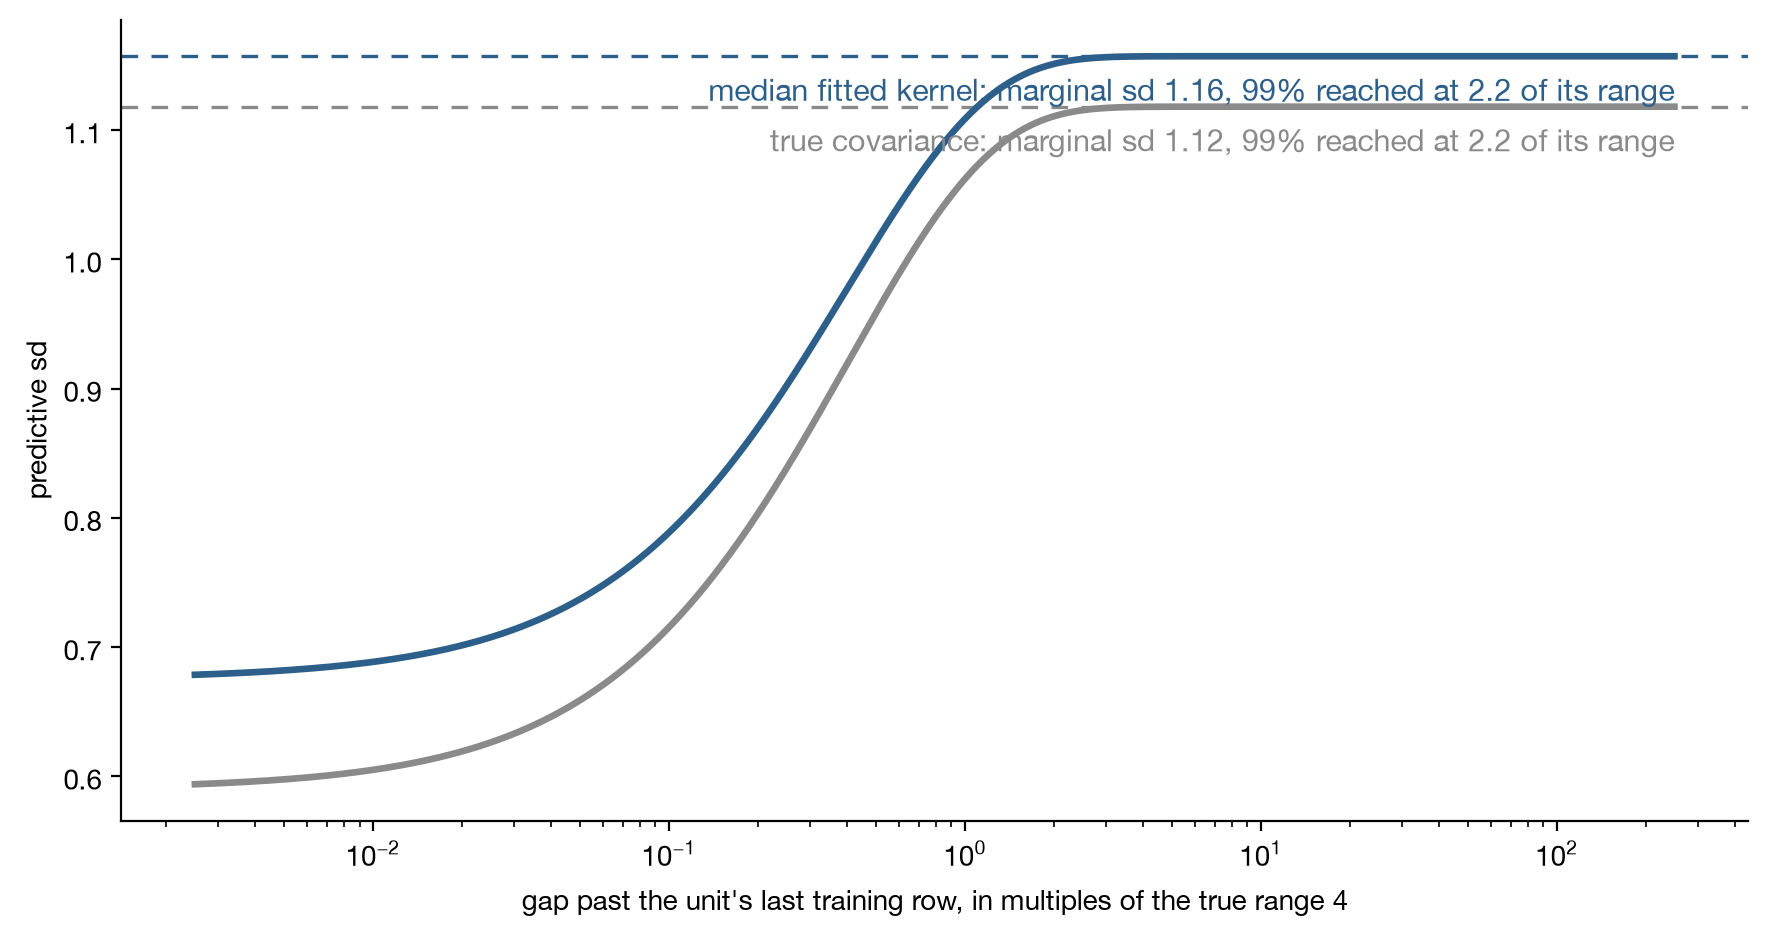

In [12]:
import matplotlib.pyplot as plt

d0 = PAN0[0]                    # the same panel the bins were cut on, untouched since
tr0 = d0[d0.t.values <= T_CUT]
n0 = tr0.groupby("unit").size().sort_values()
one = tr0[tr0.unit == n0.index[len(n0)//2]]
DT = np.logspace(-2, 3, 2000)
te0 = pd.DataFrame({"unit": one.unit.values[0], "t": one.t.values[-1] + DT})
fitted = CV[(CV.ng == BIG) & (CV.c == 0.0)][PARN].median().values
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
fig, ax = plt.subplots(figsize=(10.5, 5.2), dpi=200)
for lab, par, colour in (("true covariance", np.array([SE**2, SU**2, RHO]), "#8a8a8a"),
                         ("median fitted kernel", fitted, "#2C5F8A")):
    sd = np.sqrt(krige(one, te0, np.zeros(len(one)), par, np.zeros(len(te0)))[1])
    marg = np.sqrt(par[0] + par[1])
    share = (sd - sd[0])/(marg - sd[0])
    x95, x99 = DT[np.argmax(share >= 0.95)], DT[np.argmax(share >= 0.99)]
    print(f"{lab}: sd {sd[0]:.3f} just after the last row, marginal {marg:.3f}; 95% of the way "
          f"there at a gap of {x95:.1f} = {x95/par[2]:.2f} ranges, 99% at {x99:.1f} = "
          f"{x99/par[2]:.2f} ranges")
    ax.plot(DT/RHO, sd, color=colour, lw=2.4)
    ax.axhline(marg, color=colour, lw=1.2, ls=(0, (5, 4)))
    ax.text(DT[-1]/RHO, marg - 0.012, f"{lab}: marginal sd {marg:.2f}, 99% reached at "
            f"{x99/par[2]:.1f} of its range", ha="right", va="top", fontsize=11, color=colour)
ax.set_xscale("log")
ax.set_xlabel(f"gap past the unit's last training row, in multiples of the true range {RHO:g}")
ax.set_ylabel("predictive sd")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
plt.show()

## Stage two: the sequence arm, in its own process

The cell below writes the arm to a file so it is readable as code rather than hidden in a string,
and the cell after it runs that file. A quarter of the units is held out to choose the step to stop
at, and the net that is kept is the one from that step rather than the one at the end of the budget,
so the numbers read off it describe the model that gets scored. Those held-out units are also the
only rows on which the variance the head reports has not been fitted, which is what the diagnostic
cell later uses them for.

The budget is 400 steps, which is short on purpose. Whether it is too short is checked rather than
assumed: the stop step is printed for every fit and compared with the budget further down, and one
panel is fitted again on 3000 steps so the validation curve past that point can be read directly.

In [13]:
%%writefile grud_arm.py
"""GRU-D, Che et al. (2018) equations 4 to 6, with a Gaussian head. Imports torch and nothing
that carries a second OpenMP runtime.

The residual is the variable that stops being observed at the cut, so `delta`, the time since the
unit's last training row, is what the input decay acts on:

    gamma_x = exp(-max(0, w_x * delta + b_x))
    imputed = gamma_x * lag + (1 - gamma_x) * xbar,   with xbar = 0

`xbar` is zero because the residual has mean zero by construction. The hidden state decays by a
full matrix over the delta vector, as the paper writes it, not by a scalar:

    gamma_h = exp(-relu(W_h @ [step, delta] + b_h))

and the mask goes into the cell alongside the imputed value, again as published.
"""
import sys, time
import numpy as np, torch

HID, LR, EVERY = 24, 0.02, 25   # HID is overridable from the command line
STEPS, LONG = 400, 3000         # the budget every fit gets, and the one the probe fit gets
LAG, MASK, STEP, DELTA = 2, 3, 4, 5
PROBE = (0.5, 4.0)              # two gaps at which the fitted input decay is reported


class GRUD(torch.nn.Module):
    def __init__(self, hid=HID):
        super().__init__()
        self.cell = torch.nn.GRUCell(4, hid)         # x1, x2, imputed residual, mask
        self.head = torch.nn.Linear(hid, 2)          # mean and log variance
        self.wx = torch.nn.Linear(1, 1)              # input decay, one variable
        self.wh = torch.nn.Linear(2, hid)            # hidden decay over [step, delta]
        self.hid = hid

    def forward(self, X):
        h = X.new_zeros(X.shape[0], self.hid)
        out = []
        for k in range(X.shape[1]):
            gx = torch.exp(-torch.relu(self.wx(X[:, k, DELTA:DELTA+1])))        # eq. 4
            imp = gx*X[:, k, LAG:LAG+1]                                         # eq. 5
            gh = torch.exp(-torch.relu(self.wh(X[:, k, STEP:DELTA+1])))         # eq. 6
            h = self.cell(torch.cat([X[:, k, :2], imp, X[:, k, MASK:MASK+1]], 1), gh*h)
            out.append(self.head(h))
        return torch.stack(out, 1)


def nll(p, Y, m):
    mu, lv = p[..., 0], p[..., 1].clamp(-6, 4)
    return (0.5*(lv + (Y - mu)**2/torch.exp(lv)))[m].mean()


# the net that is kept is the one from the best validated step, not the one at the ceiling.
# `seed` is the panel's own seed, so a fit's initialisation varies with its data rather than
# every fit starting from the same weights.
def fit(X, Y, fit_m, val_m, steps, seed, hid=HID):
    torch.manual_seed(seed)
    net = GRUD(hid)
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    best_v, best_s, best_w, curve = np.inf, 0, None, []
    for s in range(1, steps + 1):
        loss = nll(net(X), Y, fit_m)
        opt.zero_grad(); loss.backward(); opt.step()
        if s % EVERY == 0:
            with torch.no_grad():
                v = float(nll(net(X), Y, val_m))
            curve.append((s, v))
            if v < best_v:
                best_v, best_s = v, s
                best_w = {k: t.detach().clone() for k, t in net.state_dict().items()}
    net.load_state_dict(best_w)                  # the scored net is the best validated one
    return net, best_s, np.array(curve)


def read(net, X):
    with torch.no_grad():
        p = net(X)
    return p[..., 0].numpy(), np.exp(p[..., 1].clamp(-6, 4).numpy())


def decay_at(net, gaps=PROBE):
    with torch.no_grad():
        d = torch.tensor([[g] for g in gaps])
        return torch.exp(-torch.relu(net.wx(d))).numpy().reshape(-1)


if __name__ == "__main__":
    torch.set_num_threads(1)     # these tensors are small: threading costs more than it buys
    z = np.load(sys.argv[1])
    hid = int(sys.argv[3]) if len(sys.argv) > 3 else HID
    pref = sys.argv[4] if len(sys.argv) > 4 else ""
    keys = [k for k in sorted({k.split("_", 1)[1] for k in z.files if k.startswith("X_")})
            if k.startswith(pref)]
    # one panel also gets the long budget, for the curve: the largest panel, path memory off
    probe = max(keys, key=lambda k: (k.split("_")[1] == "0.0", int(k.split("_")[0]),
                                     -int(k.split("_")[2])))
    out = {"budget": np.array(STEPS), "probe": np.array(probe), "hid": np.array(hid)}
    t0 = time.time()
    for k in keys:
        X, Y, mtr = (torch.as_tensor(z[f"{n}_{k}"]) for n in ("X", "Y", "mtr"))
        hold = torch.as_tensor(z[f"hold_{k}"])[:, None]
        sd = int(k.split("_")[2])                # the panel's seed, so the init varies too
        net, stop, _ = fit(X, Y, mtr & ~hold, mtr & hold, STEPS, seed=sd, hid=hid)
        out[f"mu_{k}"], out[f"var_{k}"] = read(net, X)
        out[f"stop_{k}"], out[f"gx_{k}"] = np.array(stop), decay_at(net)
        gx = out[f"gx_{k}"]
        print(f"  {k} hid {hid} stop {stop:>4}/{STEPS}, input decay {gx[0]:.3f} at {PROBE[0]} "
              f"and {gx[1]:.3f} at {PROBE[1]}  {time.time() - t0:.0f}s", flush=True)
        if k == probe:
            _, lstop, out["long_curve"] = fit(X, Y, mtr & ~hold, mtr & hold, LONG, seed=sd,
                                              hid=hid)
            print(f"  {k} again on {LONG} steps: best step {lstop}  {time.time() - t0:.0f}s",
                  flush=True)
    np.savez(sys.argv[2], **out)
    print(f"{time.time() - t0:.0f}s")

Overwriting grud_arm.py


In [14]:
!{sys.executable} grud_arm.py seq8.npz gru8.npz

  120_0.0_0 hid 24 stop   25/400, input decay 1.000 at 0.5 and 1.000 at 4.0  3s


  120_0.0_1 hid 24 stop   25/400, input decay 0.837 at 0.5 and 0.260 at 4.0  5s


  120_0.0_2 hid 24 stop   25/400, input decay 0.785 at 0.5 and 1.000 at 4.0  8s


  120_0.0_3 hid 24 stop   25/400, input decay 0.858 at 0.5 and 0.057 at 4.0  10s


  120_0.0_4 hid 24 stop   25/400, input decay 1.000 at 0.5 and 1.000 at 4.0  12s


...

  480_2.0_0 hid 24 stop   75/400, input decay 1.000 at 0.5 and 1.000 at 4.0  90s


  480_2.0_1 hid 24 stop   75/400, input decay 0.628 at 0.5 and 0.051 at 4.0  95s


  480_2.0_2 hid 24 stop  100/400, input decay 0.509 at 0.5 and 0.047 at 4.0  100s


  480_2.0_3 hid 24 stop   75/400, input decay 0.731 at 0.5 and 0.093 at 4.0  105s


  480_2.0_4 hid 24 stop   75/400, input decay 1.000 at 0.5 and 1.000 at 4.0  110s
110s


## The tables

The GRU arm appears three times. Once as it comes; once with its variance multiplied by the factor
that gives 90% coverage on the held-out units, which is the repair a practitioner can actually
compute; and once by the factor the target rows themselves ask for, which no practitioner has but
which is the best any single number can do. Read the third row to see whether the failure is a
level or a slope, since the best scalar removes the level by construction.

In [15]:
ARMS = ["pooled", "+ ewma", "+ kernel", "+ both", "+ both, joint", "+ GRU-D", "+ GRU-D, rescaled",
        "+ GRU-D, best scalar", "oracle"]
COLS = ["rmse", "cov90", "width"] + WCOL + CCOL


# how far the 90% width travels from the first gap bin to the last, and the coverage at each end
def span(w, cv, arm, pad):
    a, b = w.loc[arm].iloc[0], w.loc[arm].iloc[-1]
    return (f"  {arm:>{pad}}: width {a:.2f} to {b:.2f} ({b/a - 1:+.0%}), coverage "
            f"{cv.loc[arm].iloc[0]:.3f} to {cv.loc[arm].iloc[-1]:.3f}")


# the residual the head got wrong, in units of the sd it reported. The multiplier that sd would
# need for 90% coverage is one number off this, whole or split by the gap, and both tables below
# are that one number at two granularities.
def absz(resid, mu, var, rows):
    return pd.Series(np.abs(resid[rows] - mu[rows])/np.sqrt(var[rows]))


def needs(z):
    return z.quantile(0.90)/Z90


def head_on(resid, mu, var, rows):
    sd, e = np.sqrt(var[rows]), resid[rows] - mu[rows]
    return {"sd": sd.mean(), "resid": np.sqrt((e**2).mean()),
            "needs": needs(absz(resid, mu, var, rows))}


# the same multiplier split by the gap, because the two row sets do not share a gap
# distribution. The row counts come with it: the long bins of the training set are thin.
def needs_by_gap(resid, mu, var, gap, rows):
    g = absz(resid, mu, var, rows).groupby(gbin(gap[rows]), observed=True)
    return {**(g.quantile(0.90)/Z90).to_dict(), **{f"n {b}": v for b, v in g.size().items()}}


# one panel's worth of the arm's output, put back in panel order. The sequences were built
# unit by unit over a frame already sorted by unit and time, so dropping the padding is enough.
def unpack(G, k, v):
    real = v["pos"].reshape(-1) >= 0
    return tuple(G[f"{n}_{k}"].reshape(-1)[real] for n in ("mu", "var"))


GR = np.load("gru8.npz")
rows, meta, byg = [], [], []
for k, v in keep.items():
    te, fx, base, resid, pos = v["te"], v["fx"], v["base"], v["resid"], v["pos"]
    mu, var = unpack(GR, k, v)
    i = te.index.values
    # the training rows of the units the arm held out: the only rows outside its training loss
    hp = pos[v["hold"]].reshape(-1)
    hp = hp[hp >= 0]
    hp = hp[v["is_tr"][hp]]
    held, targ = (head_on(resid, mu, var, sel) for sel in (hp, i))
    fac = held["needs"]
    rows.append(dict(score("+ GRU-D", te, fx + mu[i], var[i]), **base))
    rows.append(dict(score("+ GRU-D, rescaled", te, fx + mu[i], var[i]*fac**2), **base))
    # and rescaled by the factor the target rows themselves ask for, which is the best a scalar
    # can do and is therefore the honest test of whether the failure is a level or a slope
    rows.append(dict(score("+ GRU-D, best scalar", te, fx + mu[i],
                           var[i]*targ["needs"]**2), **base))
    meta.append(dict(base, stop=int(GR[f"stop_{k}"]),
                     gx_near=float(GR[f"gx_{k}"][0]), gx_far=float(GR[f"gx_{k}"][1]),
                     **{f"held {a}": b for a, b in held.items()},
                     **{f"target {a}": b for a, b in targ.items()}))
    for lab, sel in (("held-out training", hp), ("target", i)):
        byg.append(dict(base, rows=lab, **needs_by_gap(resid, mu, var, v["gap"], sel)))
A = pd.concat([R, pd.DataFrame(rows)], ignore_index=True)
MT, HB = pd.DataFrame(meta), pd.DataFrame(byg)
for ng in SIZES:
    for c in CS:
        print(f"\n{ng} units, path memory {CLAB[c]}")
        print(A[(A.ng == ng) & (A.c == c)].groupby("arm")[COLS].mean()
              .reindex(ARMS).round(3).to_string())


120 units, path memory off
                       rmse  cov90  width  w <1.10  w 1.10-1.80  w 1.80-2.45  w 2.45-3.15  w 3.15-3.80  w >3.80  cov <1.10  cov 1.10-1.80  cov 1.80-2.45  cov 2.45-3.15  cov 3.15-3.80  cov >3.80
arm                                                                                                                                                                                              
pooled                1.200  0.922  4.243    4.243        4.243        4.243        4.243        4.243    4.243      0.932          0.919          0.916          0.917          0.933      0.919
+ ewma                1.253  0.921  4.373    4.373        4.373        4.373        4.373        4.373    4.373      0.932          0.917          0.911          0.921          0.917      0.929
+ kernel              1.076  0.922  3.767    3.240        3.588        3.778        3.906        3.996    4.068      0.917          0.911          0.913          0.926          0.924      0.941
+ 

In [16]:
# the two contrasts the tables are for, paired by seed
RM = A[A.ng == BIG].pivot_table(index=["c", "seed"], columns="arm", values="rmse")
p = RM
for c in CS:
    q = p.loc[c]
    print(f"{BIG} units, path memory {CLAB[c]}: pooled {q.pooled.mean():.3f}, oracle "
          f"{q.oracle.mean():.3f}")
    for arm in ("+ kernel", "+ ewma", "+ both", "+ both, joint", "+ GRU-D"):
        cl = (q.pooled - q[arm])/(q.pooled - q.oracle)
        print(f"  {arm:>13} closes {cl.mean():.0%} of the distance to the oracle, per seed "
              f"{band(cl)}")
print()
# and the width's response to the gap, which is the quantity the identity above is about
sub = A[(A.ng == BIG) & (A.c == 0.0)].groupby("arm")
w, cv = sub[WCOL].mean(), sub[CCOL].mean()
print(f"{BIG} units, path memory off: how far the 90% width travels from the shortest gap bin to the")
print("longest, and what coverage it delivers at each end")
for arm in ARMS:
    print(span(w, cv, arm, 20))
print()
# how often that coverage decline is monotone bin to bin, rather than merely lower at the end
for c in CS:
    per = A[(A.ng == BIG) & (A.c == c) & (A.arm == "+ GRU-D")][CCOL]
    dec = (per.diff(axis=1).iloc[:, 1:] <= 0).all(axis=1)
    print(f"{BIG} units, path memory {CLAB[c]}: GRU-D's coverage falls from the "
          f"first bin to the last on {(per[CCOL[-1]] < per[CCOL[0]]).sum()} of {NSEED} seeds and "
          f"is monotone on {dec.sum()}")

480 units, path memory off: pooled 1.155, oracle 0.977
       + kernel closes 75% of the distance to the oracle, per seed 0.748 [0.716, 0.788]
         + ewma closes -10% of the distance to the oracle, per seed -0.100 [-0.153, -0.064]
         + both closes 60% of the distance to the oracle, per seed 0.599 [0.557, 0.678]
  + both, joint closes 58% of the distance to the oracle, per seed 0.578 [0.498, 0.649]
        + GRU-D closes 54% of the distance to the oracle, per seed 0.538 [0.120, 0.717]
480 units, path memory on: pooled 1.693, oracle 0.977
       + kernel closes 13% of the distance to the oracle, per seed 0.127 [0.118, 0.134]
         + ewma closes 36% of the distance to the oracle, per seed 0.364 [0.333, 0.442]
         + both closes 50% of the distance to the oracle, per seed 0.496 [0.463, 0.558]
  + both, joint closes 49% of the distance to the oracle, per seed 0.492 [0.462, 0.531]
        + GRU-D closes 23% of the distance to the oracle, per seed 0.226 [0.169, 0.283]

480 un

## What the head's variance is calibrated for

The kernel arm's variance comes from a likelihood over out-of-fold residuals, and its response to
the gap is a consequence of the covariance function rather than something fitted at the gaps that
happen to be in the data. The head's variance is fitted, so the question is what it is fitted to
match.

The first table reads three numbers twice: on the training rows of the units the arm held out, and
on the target rows it is asked to serve. Those held-out rows are not in the training loss, though
their likelihood is what picks the stopping step, so they are cheap but not pristine.

That comparison on its own would be misleading, and the second table is why. The two row sets do not
share a gap distribution: a training row's gap is the step from the previous observation and a
target row's is the distance past the cut, so the aggregate difference between them mixes the effect
of being unseen with the effect of being further away. Splitting the same multiplier by gap
separates the two, with the row counts printed beside it because the long bins of the training set
are thin. The answer is the sharper version of the finding, and it is not the one the aggregate
suggests.

Two more readings follow. GRU-D's input decay is reported at two gaps, which is where the flat part
of `max(0, .)` shows up: a gate of exactly 1 means the published mechanism contributed nothing and
the hidden decay did the work. And one panel's validation curve is printed over the long budget, so
the alternative explanation, that the head is simply undertrained, can be checked rather than
dismissed.

In [17]:
KEYS = ["stop", "held sd", "held resid", "held needs", "target sd", "target resid", "target needs"]
print(MT.groupby(["ng", "c"])[KEYS].mean().round(3).to_string())
print("\nthe multiplier the head's sd needs for 90% coverage, per seed")
for (ng, c), v in MT.groupby(["ng", "c"]):
    print(f"  {ng} units, path memory {CLAB[c]}: held-out training rows "
          f"{band(v['held needs'])}, target rows {band(v['target needs'])}")

         stop  held sd  held resid  held needs  target sd  target resid  target needs
ng  c                                                                                
120 0.0  25.0    0.980       0.989       1.021      0.980         1.144         1.169
    2.0  50.0    1.201       1.273       1.063      1.267         1.605         1.294
480 0.0  60.0    0.830       0.858       1.026      0.881         1.056         1.201
    2.0  80.0    1.006       1.079       1.052      1.223         1.531         1.244

the multiplier the head's sd needs for 90% coverage, per seed
  120 units, path memory off: held-out training rows 1.021 [0.930, 1.138], target rows 1.169 [1.063, 1.258]
  120 units, path memory on: held-out training rows 1.063 [1.017, 1.166], target rows 1.294 [1.210, 1.451]
  480 units, path memory off: held-out training rows 1.026 [0.998, 1.043], target rows 1.201 [1.180, 1.219]
  480 units, path memory on: held-out training rows 1.052 [1.023, 1.096], target rows 1.244 [1.160

In [18]:
NCOL = [f"n {b}" for b in GAPL]
sub = HB[HB.ng == BIG].groupby(["c", "rows"])
print(f"the same multiplier by the gap to the unit's last training row, {BIG} units")
print(sub[GAPL].mean().where(sub[NCOL].mean().values >= 50).round(3).to_string())
print("a bin with fewer than 50 rows per panel is left blank rather than read off a handful of rows")
print("\nrows behind each of those, per panel")
print(sub[NCOL].mean().round(0).to_string())
tg = HB[(HB.ng == BIG) & (HB.c == 0.0) & (HB.rows == "target")][GAPL].mean()
print(f"\nread down a column, not across a row. On the target rows the multiplier rises with the "
      f"gap,\n{tg.iloc[0]:.2f} in the nearest bin to {tg.iloc[-1]:.2f} in the farthest, and the "
      f"training rows sit almost entirely in\nthe short bins where it is near one.")
print("\nhow much of the aggregate contrast is only that difference in gap mix: put the target")
print("rows' per-bin multipliers on the training rows' gap distribution and see what survives")
for c in CS:
    t = HB[(HB.ng == BIG) & (HB.c == c) & (HB.rows == "target")][GAPL].mean().values
    wt = HB[(HB.ng == BIG) & (HB.c == c) & (HB.rows == "held-out training")][NCOL].mean().values
    ok = ~np.isnan(t) & ~np.isnan(wt)
    mixed = (t[ok]*wt[ok]).sum()/wt[ok].sum()
    q = MT[(MT.ng == BIG) & (MT.c == c)]
    held, targ = q["held needs"].mean(), q["target needs"].mean()
    print(f"  path memory {CLAB[c]}: held {held:.3f}, target {targ:.3f}, the target rows on the "
          f"training gap mix {mixed:.3f}")
    print(f"    so gap mix accounts for {(targ - mixed)/(targ - held):.0%} of the contrast, and "
          f"{mixed - held:+.3f} of it survives")
print("\nso gap mix is part of the contrast and the rest is the row being unseen, in a share that")
print("depends on the truth. Either way one scalar cannot straighten the slope.")

the same multiplier by the gap to the unit's last training row, 480 units
                       <1.10  1.10-1.80  1.80-2.45  2.45-3.15  3.15-3.80  >3.80
c   rows                                                                       
0.0 held-out training  1.017      1.055        NaN        NaN        NaN    NaN
    target             1.064      1.138      1.220      1.208      1.254  1.309
2.0 held-out training  1.038      1.135        NaN        NaN        NaN    NaN
    target             1.171      1.201      1.259      1.277      1.273  1.299
a bin with fewer than 50 rows per panel is left blank rather than read off a handful of rows

rows behind each of those, per panel
                       n <1.10  n 1.10-1.80  n 1.80-2.45  n 2.45-3.15  n 3.15-3.80  n >3.80
c   rows                                                                                   
0.0 held-out training   1545.0        135.0         23.0          5.0          1.0      NaN
    target               644.0        6

### The multiplier with a band that respects the units

The same multiplier, pooled over the five large panels, for GRU-D and the kernel arm on the same
bins. Rows of one unit share its effect, so they are not independent draws, and a band that treats
them as such is too narrow. The band here resamples whole units, with Poisson weights, and the
row-level band is printed beside it to show how much it understates.


480 units, path memory off: the multiplier for 90% coverage, 95% band by unit
     arm       bin  rows   gap  multiplier         band    rows_band
 + GRU-D     <1.10  3222 0.684       1.069 [1.04, 1.10] [1.04, 1.10]
 + GRU-D 1.10-1.80  3216 1.474       1.138 [1.08, 1.18] [1.09, 1.18]
 + GRU-D 1.80-2.45  3048 2.151       1.217 [1.18, 1.25] [1.18, 1.25]
 + GRU-D 2.45-3.15  3287 2.819       1.223 [1.18, 1.26] [1.18, 1.26]
 + GRU-D 3.15-3.80  3086 3.482       1.241 [1.21, 1.30] [1.21, 1.30]
 + GRU-D     >3.80  3112 4.288       1.314 [1.27, 1.36] [1.28, 1.36]
+ kernel     <1.10  3222 0.684       0.999 [0.97, 1.04] [0.98, 1.04]
+ kernel 1.10-1.80  3216 1.474       1.004 [0.96, 1.04] [0.96, 1.04]
+ kernel 1.80-2.45  3048 2.151       0.996 [0.97, 1.04] [0.97, 1.04]
+ kernel 2.45-3.15  3287 2.819       0.990 [0.96, 1.03] [0.96, 1.02]
+ kernel 3.15-3.80  3086 3.482       0.961 [0.93, 1.00] [0.93, 1.00]
+ kernel     >3.80  3112 4.288       1.008 [0.97, 1.05] [0.97, 1.03]
  resampling units inste

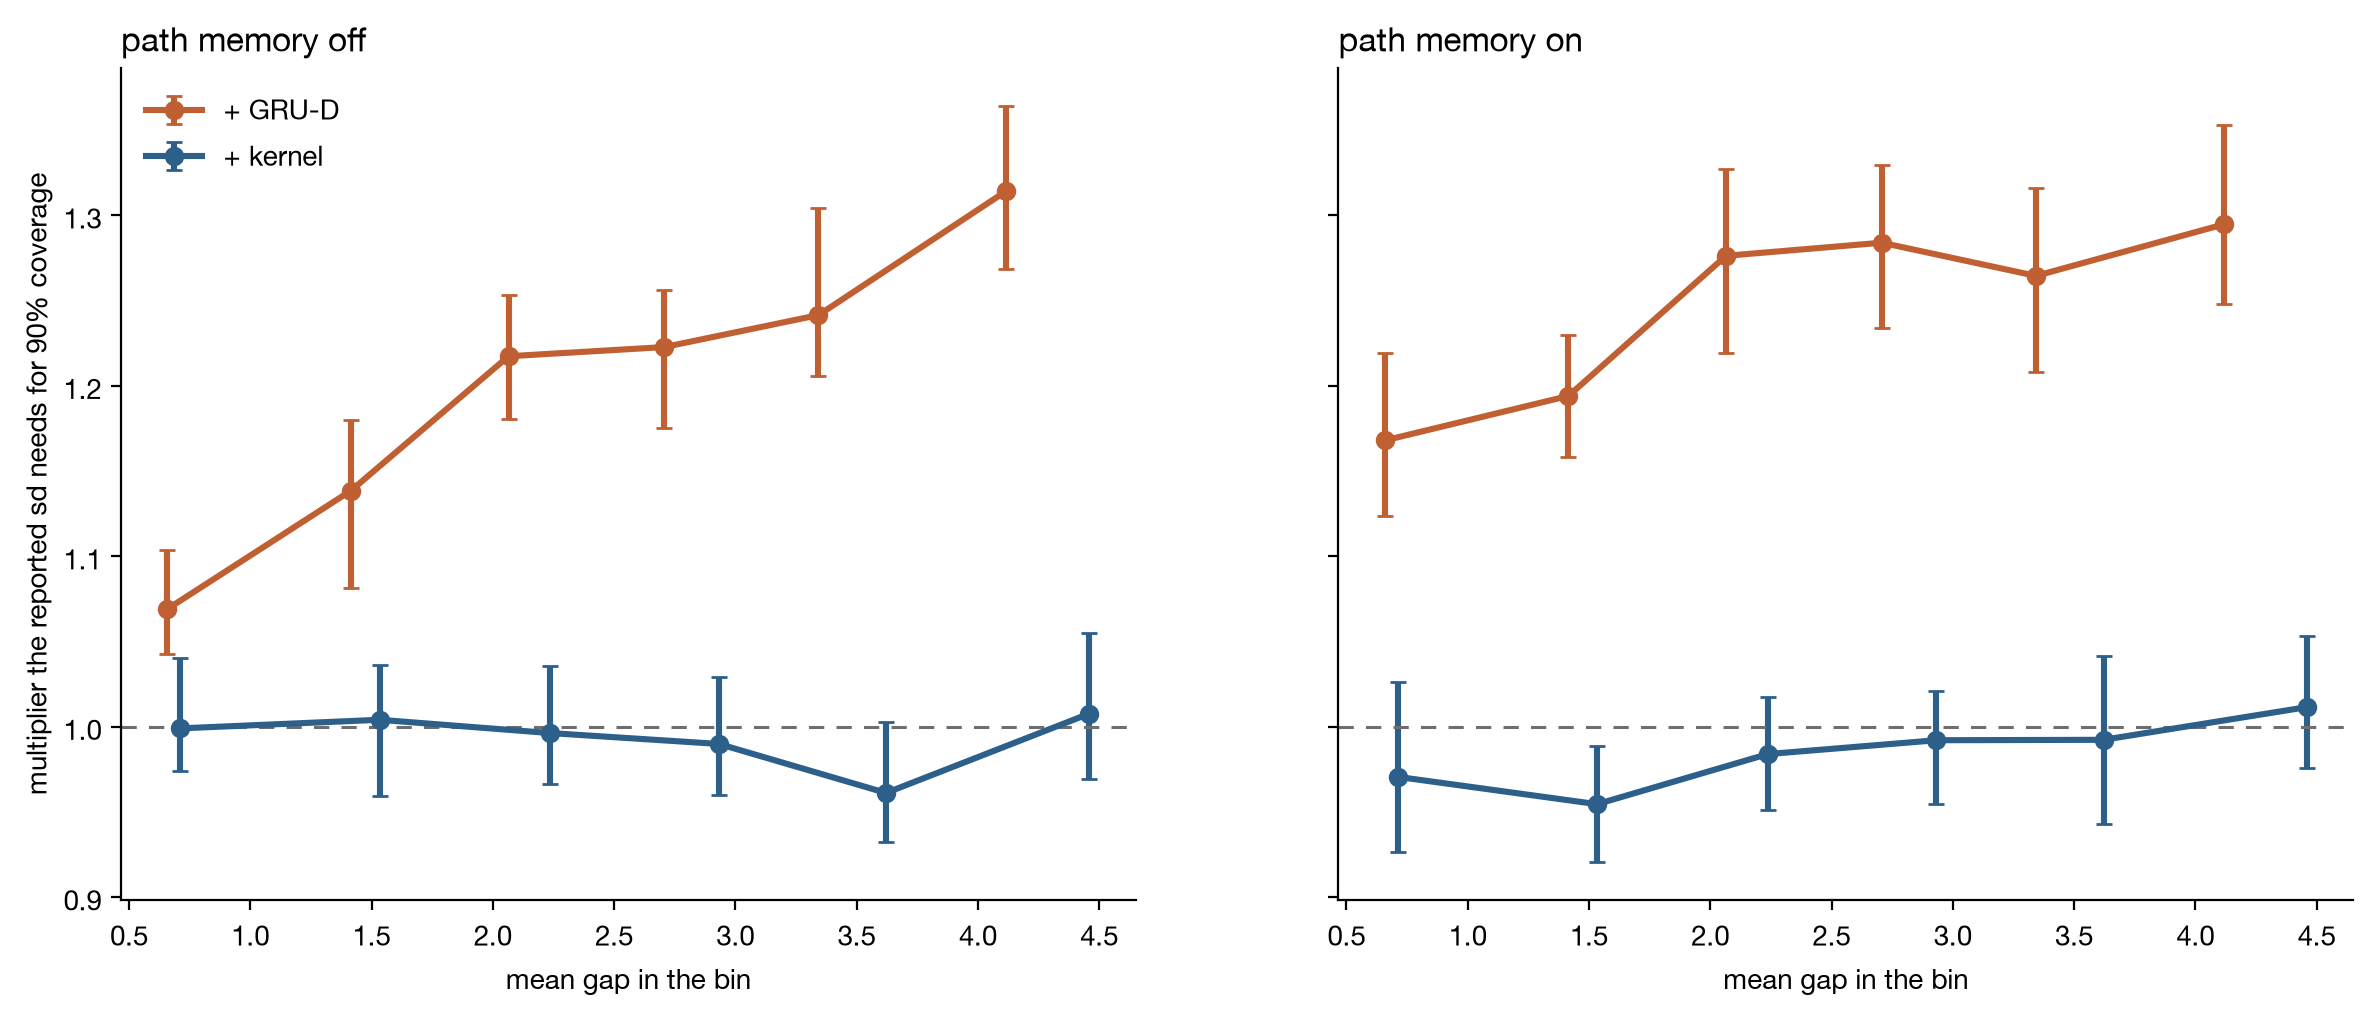

In [19]:
B_REPS = 500


# the multiplier on 90% coverage, from sorted |z| and one row of weights per replicate
def mult(zs, W):
    cw = np.cumsum(W, axis=1)
    return zs[np.argmax(cw >= 0.9*cw[:, -1:], axis=1)]/Z90


def mult_band(z, clu, seed=0):
    o = np.argsort(z)
    zs, ci = z[o], np.unique(clu[o], return_inverse=True)[1]
    rng = np.random.default_rng(seed)
    by_unit = mult(zs, rng.poisson(1.0, (B_REPS, ci.max() + 1))[:, ci])
    by_row = mult(zs, rng.poisson(1.0, (B_REPS, len(zs))))
    return {"multiplier": float(mult(zs, np.ones((1, len(zs))))[0]),
            "lo": np.quantile(by_unit, 0.025), "hi": np.quantile(by_unit, 0.975),
            "lo, rows": np.quantile(by_row, 0.025), "hi, rows": np.quantile(by_row, 0.975)}


zr = []
for k, v in keep.items():
    b = v["base"]
    if b["ng"] != BIG:
        continue
    te, i = v["te"], v["te"].index.values
    gmu, gvar = unpack(GR, k, v)
    for arm, (mu, var) in (("+ GRU-D", (v["fx"] + gmu[i], gvar[i])), ("+ kernel", v["kern"]),
                           ("+ both", v["both"]), ("+ both, joint", v["joint"])):
        zr.append(pd.DataFrame({"c": b["c"], "arm": arm, "unit": b["seed"]*10**6 + te.unit.values,
                                "gap": te.gap.values,
                                "z": np.abs(te.y.values - mu)/np.sqrt(var)}))
ZR = pd.concat(zr, ignore_index=True)
ZR["bin"] = gbin(ZR.gap.values)
MB = pd.DataFrame([dict(c=c, arm=arm, bin=bn, rows=len(q), gap=q.gap.mean(),
                        **mult_band(q.z.values, q.unit.values))
                   for (c, arm, bn), q in ZR.groupby(["c", "arm", "bin"], observed=True)])
for c in CS:
    print(f"\n{BIG} units, path memory {CLAB[c]}: the multiplier for 90% coverage, 95% band by unit")
    t = MB[(MB.c == c) & MB.arm.isin(["+ GRU-D", "+ kernel"])]
    print(t.assign(band=t.apply(lambda r: f"[{r.lo:.2f}, {r.hi:.2f}]", axis=1),
                   rows_band=t.apply(lambda r: f"[{r['lo, rows']:.2f}, {r['hi, rows']:.2f}]", axis=1))
          [["arm", "bin", "rows", "gap", "multiplier", "band", "rows_band"]]
          .round(3).to_string(index=False))
    w = (t.hi - t.lo)/(t["hi, rows"] - t["lo, rows"])       # the two arms just printed, not all four
    print(f"  resampling units instead of rows widens the band by {w.median():.2f}x at the median")

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.4), dpi=200, sharey=True)
for ax, c in zip(axes, CS):
    for arm, colour, dx in (("+ GRU-D", "#C05F32", -0.04), ("+ kernel", "#2C5F8A", 0.04)):
        q = MB[(MB.c == c) & (MB.arm == arm)]
        ax.errorbar(q.gap*(1 + dx), q.multiplier, yerr=[q.multiplier - q.lo, q.hi - q.multiplier],
                    color=colour, marker="o", ms=6, lw=2.2, capsize=3, label=arm)
    ax.axhline(1.0, color="#6e6e6e", lw=1.1, ls=(0, (5, 4)))
    ax.set_title(f"path memory {CLAB[c]}", loc="left")
    ax.set_xlabel("mean gap in the bin")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel("multiplier the reported sd needs for 90% coverage")
axes[0].legend(frameon=False)
plt.show()

### Two stages against a joint fit

The `+ both` arm fits the covariance to residuals of a mean function it treats as fixed. That is a
two-stage estimate, and the second stage does not see the uncertainty of the first. `+ both, joint`
estimates the same model in one pass. The comparison is on accuracy, on coverage by gap bin, and on
how far apart the two intervals are row by row.

In [20]:
J = A[(A.ng == BIG) & A.arm.isin(["+ both", "+ both, joint"])]
for c in CS:
    print(f"\n{BIG} units, path memory {CLAB[c]}")
    print(J[J.c == c].groupby("arm")[["rmse", "cov90", "width"] + CCOL].mean().round(3).to_string())
print("\nfitted covariance, two stages against joint, mean over seeds")
print(CV[CV.ng == BIG].groupby("c")[[f"{n} ewma" for n in PARN] + [f"{n} joint" for n in PARN]]
      .mean().round(3).to_string())
ratio = []
for k, v in keep.items():
    if v["base"]["ng"] != BIG:
        continue
    ratio.append(pd.DataFrame({"c": v["base"]["c"], "bin": gbin(v["te"].gap.values),
                               "sd ratio": np.sqrt(v["joint"][1]/v["both"][1])}))
SR = pd.concat(ratio).groupby(["c", "bin"], observed=True)["sd ratio"]
stats = pd.DataFrame({"median": SR.median(), "p10": SR.quantile(0.1), "p90": SR.quantile(0.9)})
print("\nthe joint interval over the two-stage one, row by row: median, and 10th to 90th percentile")
print(stats.round(3).unstack("bin")["median"].to_string())
print(stats[["p10", "p90"]].round(3).to_string())


480 units, path memory off
                rmse  cov90  width  cov <1.10  cov 1.10-1.80  cov 1.80-2.45  cov 2.45-3.15  cov 3.15-3.80  cov >3.80
arm                                                                                                                 
+ both         1.048  0.898  3.444      0.892          0.897          0.896          0.903          0.902      0.899
+ both, joint  1.051  0.747  2.436      0.611          0.731          0.757          0.785          0.793      0.807

480 units, path memory on
                rmse  cov90  width  cov <1.10  cov 1.10-1.80  cov 1.80-2.45  cov 2.45-3.15  cov 3.15-3.80  cov >3.80
arm                                                                                                                 
+ both         1.337  0.901  4.330      0.903          0.909          0.899          0.894          0.905      0.894
+ both, joint  1.340  0.782  3.278      0.682          0.764          0.787          0.814          0.819      0.832

fitted c

In [21]:
print("GRU-D's input decay, exp(-max(0, W delta + b)), at gaps of 0.5 and 4.0")
print(MT[["ng", "c", "seed", "gx_near", "gx_far"]].round(4).to_string(index=False))
off = ((MT.gx_near == 1.0) & (MT.gx_far == 1.0)).sum()
print(f"\nthe gate is exactly 1 at both gaps in {off} of {len(MT)} fits, so in those the input "
      f"decay is switched\noff entirely and the hidden-state decay carries the gap on its own")

GRU-D's input decay, exp(-max(0, W delta + b)), at gaps of 0.5 and 4.0
 ng   c  seed  gx_near  gx_far
120 0.0     0   1.0000  1.0000
120 0.0     1   0.8366  0.2603
120 0.0     2   0.7847  1.0000
120 0.0     3   0.8578  0.0571
120 0.0     4   1.0000  1.0000
120 2.0     0   1.0000  1.0000
120 2.0     1   0.6240  0.0580
120 2.0     2   0.7399  0.4837
120 2.0     3   0.6497  0.0181
120 2.0     4   1.0000  1.0000
480 0.0     0   1.0000  1.0000
480 0.0     1   0.8082  0.1877
480 0.0     2   0.6598  0.4321
480 0.0     3   1.0000  0.1718
480 0.0     4   1.0000  1.0000
480 2.0     0   1.0000  1.0000
480 2.0     1   0.6280  0.0515
480 2.0     2   0.5091  0.0472
480 2.0     3   0.7314  0.0934
480 2.0     4   1.0000  1.0000

the gate is exactly 1 at both gaps in 8 of 20 fits, so in those the input decay is switched
off entirely and the hidden-state decay carries the gap on its own


In [22]:
cu = GR["long_curve"]
print(f"validation loss over the long budget, panel {str(GR['probe'])}, every "
      f"{int(cu[1, 0] - cu[0, 0])} steps")
for j in range(0, len(cu), 12):
    print(f"  step {int(cu[j, 0]):>4}: {cu[j, 1]:+.4f}")
b = cu[cu[:, 1].argmin()]
print(f"  best step {int(b[0])} at {b[1]:+.4f}; at the ceiling, step {int(cu[-1, 0])}, "
      f"{cu[-1, 1]:+.4f}, which is {cu[-1, 1] - b[1]:+.3f} worse")
bud = int(GR["budget"])
print(f"the scored fits had a budget of {bud} steps and stopped between {MT.stop.min()} and "
      f"{MT.stop.max()}, so the worst case used {MT.stop.max()/bud:.0%} of it")

validation loss over the long budget, panel 480_0.0_0, every 25 steps
  step   25: +0.3360
  step  325: +1.5984
  step  625: +0.4069
  step  925: +1.9672
  step 1225: +1.4465
  step 1525: +2.3327
  step 1825: +0.7408
  step 2125: +1.3962
  step 2425: +3.5630
  step 2725: +0.5377
  best step 75 at +0.3198; at the ceiling, step 3000, +1.4376, which is +1.118 worse
the scored fits had a budget of 400 steps and stopped between 25 and 100, so the worst case used 25% of it


## Is the slope the architecture, or the 24 hidden units?

The cell above rules out one alternative explanation, undertraining, and leaves a bigger one alone.
The head has `HID` hidden units, and that number was chosen for speed rather than measured. If the
coverage slope is what an underfitted mean looks like rather than what a fitted variance does, then
raising the capacity should flatten it.

So the same arm is refitted with a much wider state on the large panels, everything else held: same
sequences, same held-out units, same budget, same early stopping, same initialisation per seed. This
is the expensive cell in the notebook and it is the one that decides how much of the finding is
about GRU-D and how much is about a hyperparameter.

In [23]:
WIDE = 128
!{sys.executable} grud_arm.py seq8.npz gru8_wide.npz {WIDE} {BIG}_

  480_0.0_0 hid 128 stop   25/400, input decay 0.998 at 0.5 and 0.283 at 4.0  15s


  480_0.0_0 again on 3000 steps: best step 25  116s


  480_0.0_1 hid 128 stop   50/400, input decay 1.000 at 0.5 and 1.000 at 4.0  129s


  480_0.0_2 hid 128 stop   25/400, input decay 1.000 at 0.5 and 1.000 at 4.0  143s


  480_0.0_3 hid 128 stop   50/400, input decay 0.522 at 0.5 and 0.570 at 4.0  157s


...

  480_2.0_0 hid 128 stop   25/400, input decay 0.743 at 0.5 and 0.108 at 4.0  184s


  480_2.0_1 hid 128 stop   25/400, input decay 1.000 at 0.5 and 1.000 at 4.0  197s


  480_2.0_2 hid 128 stop   25/400, input decay 1.000 at 0.5 and 1.000 at 4.0  211s


  480_2.0_3 hid 128 stop   50/400, input decay 0.469 at 0.5 and 0.322 at 4.0  224s


  480_2.0_4 hid 128 stop   50/400, input decay 1.000 at 0.5 and 1.000 at 4.0  238s
238s


In [24]:
GW = np.load("gru8_wide.npz")
narrow_hid, wrows = int(GR["hid"]), []
for k, v in keep.items():
    if not k.startswith(f"{BIG}_"):
        continue
    te, fx, base, resid = v["te"], v["fx"], v["base"], v["resid"]
    mu, var = unpack(GW, k, v)
    i = te.index.values
    wrows.append(dict(score(f"+ GRU-D, {int(GW['hid'])} hidden", te, fx + mu[i], var[i]), **base,
                      needs=head_on(resid, mu, var, i)["needs"],
                      **{f"g {b}": x for b, x in
                         needs_by_gap(resid, mu, var, v["gap"], i).items() if not b.startswith("n ")}))
W = pd.DataFrame(wrows)
NARROW = A[(A.ng == BIG) & (A.arm == "+ GRU-D")]
for c in CS:
    print(f"\n{BIG} units, path memory {CLAB[c]}")
    for lab, d, nd in ((f"hid {narrow_hid}", NARROW[NARROW.c == c],
                        MT[(MT.ng == BIG) & (MT.c == c)]["target needs"]),
                       (f"hid {int(GW['hid'])}", W[W.c == c], W[W.c == c].needs)):
        w, cv = d[WCOL].mean(), d[CCOL].mean()
        print(f"  {lab:>8}: rmse {d.rmse.mean():.3f}, width {w.iloc[0]:.2f} to {w.iloc[-1]:.2f} "
              f"({w.iloc[-1]/w.iloc[0] - 1:+.0%}), coverage {cv.iloc[0]:.3f} to {cv.iloc[-1]:.3f}, "
              f"multiplier {nd.mean():.3f}")
    q = RM.loc[c]
    for lab, r in ((f"hid {narrow_hid}", NARROW[NARROW.c == c].set_index("seed").rmse),
                   (f"hid {int(GW['hid'])}", W[W.c == c].set_index("seed").rmse)):
        cl = (q.pooled - r)/(q.pooled - q.oracle)
        print(f"  {lab:>8}: closes {cl.mean():.0%} of the distance to the oracle, per seed "
              f"{band(cl)}")
gb = [f"g {b}" for b in GAPL]
print(f"\nthe multiplier the wider head needs, by gap bin, {BIG} units")
print(W.groupby("c")[gb].mean().round(3).to_string())


480 units, path memory off
    hid 24: rmse 1.056, width 2.70 to 2.98 (+10%), coverage 0.874 to 0.800, multiplier 1.201
   hid 128: rmse 1.074, width 2.75 to 3.08 (+12%), coverage 0.880 to 0.797, multiplier 1.188
    hid 24: closes 54% of the distance to the oracle, per seed 0.538 [0.120, 0.717]
   hid 128: closes 45% of the distance to the oracle, per seed 0.452 [0.238, 0.667]

480 units, path memory on
    hid 24: rmse 1.531, width 3.34 to 4.34 (+30%), coverage 0.850 to 0.800, multiplier 1.244
   hid 128: rmse 1.583, width 3.39 to 4.14 (+22%), coverage 0.837 to 0.758, multiplier 1.320


    hid 24: closes 23% of the distance to the oracle, per seed 0.226 [0.169, 0.283]
   hid 128: closes 15% of the distance to the oracle, per seed 0.151 [0.077, 0.329]

the multiplier the wider head needs, by gap bin, 480 units
     g <1.10  g 1.10-1.80  g 1.80-2.45  g 2.45-3.15  g 3.15-3.80  g >3.80
c                                                                        
0.0    1.063        1.130        1.191        1.189        1.253    1.309
2.0    1.199        1.222        1.350        1.383        1.352    1.378


## When the covariance family is wrong

The comparison above gives the kernel arm a truth it can express, an exponential unit effect, and
that is a real advantage: its interval extrapolates by construction, but only under the covariance
function it assumed. So the same panel is generated with the unit effect drawn from a
different family, a Matern 3/2 and a sum of two exponentials with ranges an order of magnitude
apart, while the arm keeps fitting an exponential. The exponential truth is run alongside them as
a control, on its own draw. Everything else is held fixed and the path memory is off, so the only
thing wrong is the family.

The question is not whether the fitted parameters recover anything, they cannot, but whether the
coverage still holds its level across the gap bins.

In [25]:
DIST = np.abs(GRID[:, None] - GRID[None, :])
KERN = {"exponential": cov_pair(GRID, GRID, (0.0, SU**2, RHO)),
        "Matern 3/2": SU**2*(1 + np.sqrt(3)*DIST/RHO)*np.exp(-np.sqrt(3)*DIST/RHO),
        "two exponentials": 0.5*SU**2*(np.exp(-DIST/1.0) + np.exp(-DIST/16.0))}
# the distance at which each truth's own correlation has fallen to 1/e, which is what an
# exponential range means and is the only thing the fitted range can be read against
EFOLD = {kind: GRID[np.argmax(K[0] < K[0, 0]/np.e)] for kind, K in KERN.items()}


def panel_k(seed, kind, ng=BIG):
    """The panel above with the path memory off, but the unit effect from any covariance.
    The draw is the only thing that changes, and it cannot be routed through `panel`: a
    Cholesky draw takes ng*NT normals where `ou_paths` takes ng more, which would shift the
    noise and the arrival thinning and move every number in the tables above."""
    rng = np.random.default_rng(seed)
    X1, X2 = ou_paths(rng, ng, 1.0, RHO_X), ou_paths(rng, ng, 1.0, RHO_X)
    K = KERN[kind]
    U = rng.standard_normal((ng, NT)) @ np.linalg.cholesky(K + 1e-9*np.eye(NT)).T
    return assemble(rng, X1, X2, gfun(X1, X2), U, ng)


# the same kriging as above, reading a covariance off the dense grid instead of computing it.
# Every observation time came out of GRID, so searchsorted recovers its column exactly.
def grid_cov(K):
    def cov(a, b, _):
        return K[np.ix_(np.searchsorted(GRID, a), np.searchsorted(GRID, b))]
    return cov


def oracle_k(tr, te, K):
    return krige(tr, te, tr.y.values - tr.m.values, (SE**2, K[0, 0], np.nan), te.m.values,
                 cov=grid_cov(K))

In [26]:
t0, rows = time.time(), []
for kind, K in KERN.items():
    for s in range(NSEED):
        d = panel_k(s, kind)
        m = d.t.values > T_CUT
        tr, te = d[~m], d[m]
        fx = pooled(tr, FEAT).predict(d[FEAT].values)
        r = d.y.values - fx
        r[~m] = oof(tr, s, FEAT)
        par = fit_cov(tr, r[~m])
        rows.append(dict(score("+ kernel", te, *krige(tr, te, r[~m], par, fx[m])),
                         truth=kind, seed=s, fitted_range=par[2], fitted_var=par[1]))
        rows.append(dict(score("oracle", te, *oracle_k(tr, te, K)), truth=kind, seed=s,
                         fitted_range=np.nan, fitted_var=np.nan))
MS = pd.DataFrame(rows)
for kind in KERN:
    sub = MS[MS.truth == kind]
    gb = sub.groupby("arm", sort=False)
    print(f"\ntruth: {kind}")
    print(gb[["rmse", "cov90", "width"]].mean().round(3).to_string())
    k = sub[sub.arm == "+ kernel"]
    print(f"  the exponential fit reports range {band(k.fitted_range)} and unit-effect variance "
          f"{band(k.fitted_var)} against {SU**2:.1f}. This truth's own correlation falls to 1/e "
          f"by {EFOLD[kind]:.2f},\n  which is the only quantity a fitted range can be read "
          f"against: the Matern and two-exponential families have no range parameter\n  in the "
          f"exponential sense at all")
    for arm in ("+ kernel", "oracle"):
        print(span(gb[WCOL].mean(), gb[CCOL].mean(), arm, 9))
print(f"\n{time.time() - t0:.0f}s")


truth: exponential
           rmse  cov90  width
arm                          
+ kernel  1.031  0.901  3.399
oracle    0.984  0.895  3.186
  the exponential fit reports range 4.041 [3.548, 4.332] and unit-effect variance 1.035 [0.977, 1.104] against 1.0. This truth's own correlation falls to 1/e by 4.10,
  which is the only quantity a fitted range can be read against: the Matern and two-exponential families have no range parameter
  in the exponential sense at all
   + kernel: width 2.86 to 3.71 (+30%), coverage 0.903 to 0.897
     oracle: width 2.60 to 3.52 (+35%), coverage 0.899 to 0.890

truth: Matern 3/2
           rmse  cov90  width
arm                          
+ kernel  0.968  0.891  3.081
oracle    0.901  0.895  2.889
  the exponential fit reports range 6.980 [6.405, 7.274] and unit-effect variance 1.064 [1.009, 1.167] against 1.0. This truth's own correlation falls to 1/e by 5.05,
  which is the only quantity a fitted range can be read against: the Matern and two-exponential 

## What a constant width would cost, over the gaps this panel produces

The identity cell showed the sd a correct interval needs travelling by a factor of several across a
grid of gaps. That grid was hand-picked and equally weighted, which flatters the argument: what
matters is the distribution of gaps the panel actually hands you. So the same price is computed
over every target gap in the five large panels above, with the true conditional sd at each.

In [27]:
big = [v for v in keep.values() if v["base"]["ng"] == BIG and v["base"]["c"] == 0.0]
g = np.concatenate([v["te"].gap.values for v in big])
# the oracle's own sd, which is the true conditional law given everything the unit was observed
# to do, rather than a closed form that pretends the last row was seen without noise
sd = np.concatenate([v["oracle_sd"] for v in big])
cov_at = lambda sc: 2*norm.cdf(Z90*sc/sd) - 1
sc = brentq(lambda x: cov_at(x).mean() - 0.90, 0.1, 10.0)
print(f"{len(g)} target rows; gap quantiles at 0, 5, 50, 95, 100% "
      f"{np.round(np.quantile(g, [0, 0.05, 0.5, 0.95, 1.0]), 2)}")
print(f"the true conditional sd over them runs {sd.min():.3f} to {sd.max():.3f}, a factor of "
      f"{sd.max()/sd.min():.2f}")
print(f"a constant half-width of {Z90*sc:.2f} averages 90% over that distribution and delivers")
b = gbin(g)
for lab, v in pd.Series(cov_at(sc)).groupby(b, observed=True).mean().items():
    print(f"  {lab:>6}: {v:.3f}   ({(b == lab).mean():.0%} of target rows)")
print("the worst bin is the cost of one number. It is smaller than a hand-picked grid of gaps")
print("suggests, because the panel puts most of its target rows in the middle of the range.")

18971 target rows; gap quantiles at 0, 5, 50, 95, 100% [0.05 0.55 2.45 4.35 7.  ]
the true conditional sd over them runs 0.604 to 1.106, a factor of 1.83
a constant half-width of 1.60 averages 90% over that distribution and delivers
   <1.10: 0.956   (17% of target rows)
  1.10-1.80: 0.921   (17% of target rows)
  1.80-2.45: 0.899   (16% of target rows)
  2.45-3.15: 0.884   (17% of target rows)
  3.15-3.80: 0.873   (16% of target rows)
   >3.80: 0.865   (16% of target rows)
the worst bin is the cost of one number. It is smaller than a hand-picked grid of gaps
suggests, because the panel puts most of its target rows in the middle of the range.


## Guessing the memory length

The `+ ewma` arm was handed three rates, one of them the true one. That is not the situation anyone
is in, so it is worth measuring how much of its advantage survives a wrong guess. One column at a
time, over three decades around the truth, and then two columns that straddle the truth without
either being it.

In [28]:
SCAN = np.round(np.logspace(-1.5, 1.5, 9), 3)
PAIR = (0.4, 2.5)
PAIRL = f"{PAIR[0]:g} and {PAIR[1]:g} together"
ref = RM.loc[CVAL]                      # the same rmse table the contrasts above pivoted
ENDS = RM[["pooled", "oracle"]].reset_index()
PAN = {(c, s): panel(s, c, ng=BIG)[0] for c in CS for s in range(NSEED)}


# one booster given one guessed set of exponential averages, over the same five panels
def variant(rates, cols, lab, c=CVAL):
    out = []
    for s in range(NSEED):
        d = PAN[(c, s)].copy()                   # a fresh frame, so no earlier w-columns survive
        m = d.t.values > T_CUT
        WF = add_ewma(d, rates, cols)
        p = pooled(d[~m], FEAT + WF).predict(d[FEAT + WF].values[m])
        out.append({"guess": lab, "columns given": len(WF), "seed": s, "c": c,
                    "rmse": rmse(d.y.values[m], p)})
    return out


def closed(rows):
    f = pd.DataFrame(rows).merge(ENDS, on=["c", "seed"])
    return f.assign(closed=(f.pooled - f.rmse)/(f.pooled - f.oracle))


t0 = time.time()
SC = closed([o for rates, lab in [((r,), f"{r:g}") for r in SCAN] + [(PAIR, PAIRL)]
             for o in variant(rates, truth_col, lab)])
GS = SC.groupby("guess", sort=False)[["rmse", "closed"]].mean()
print(f"the true rate is {KAPPA:g}; {BIG} units, {NSEED} seeds, path memory {CLAB[CVAL]}")
print(GS.round(3).to_string())
cl_ewma = ((ref.pooled - ref["+ ewma"])/(ref.pooled - ref.oracle)).mean()
print(f"\npooled {SC.pooled.mean():.3f}, oracle {SC.oracle.mean():.3f}, three columns including "
      f"the true rate {ref['+ ewma'].mean():.3f} ({cl_ewma:.0%})")
# and the same straddling pair on the panels with no path memory at all, which is the price of
# adding these columns when there is nothing for them to remember
OFF = closed(variant(PAIR, truth_col, PAIRL, c=0.0))
print(f"the same two columns on the panels with no path memory close {OFF.closed.mean():.0%}, "
      f"per seed {band(OFF.closed)}")
print(f"{time.time() - t0:.0f}s")

the true rate is 1; 480 units, 5 seeds, path memory on
                       rmse  closed
guess                              
0.032                 1.719  -0.036
0.075                 1.686   0.009
0.178                 1.607   0.119
0.422                 1.504   0.261
1                     1.428   0.369
2.371                 1.431   0.365
5.623                 1.481   0.295
13.335                1.518   0.243
31.623                1.540   0.213
0.4 and 2.5 together  1.427   0.370

pooled 1.693, oracle 0.977, three columns including the true rate 1.431 (36%)


the same two columns on the panels with no path memory close -7%, per seed -0.071 [-0.106, -0.042]
7s


### And if you do not know the nonlinearity either

The `+ ewma` arm was handed `beta` itself, the function the truth averages along the path. That is a
second thing to guess and a larger one than the rate. A modeller without it would average a generic
basis instead: the two covariates, their squares and their product. Same two rates as the line
above, straddling the truth, neither of them right.

One thing this basis is not is innocent. `beta` is `tanh(1.5 x1) + 0.7 x2**2 - 0.7`, so `x2**2` is
literally one of its two terms and the basis contains it. What the comparison measures is therefore
whether a spanning set costs anything against the exact function, not whether a basis blind to the
truth would do as well.

In [29]:
t0 = time.time()
BS = closed(variant(PAIR, basis_cols, "a quadratic basis"))
print(f"rates {PAIR[0]:g} and {PAIR[1]:g}, neither of them the true {KAPPA:g}; {BIG} units, "
      f"{NSEED} seeds")
print(pd.concat([BS, SC[SC.guess == PAIRL].assign(guess="beta itself")])
      .groupby("guess", sort=False)[["columns given", "rmse", "closed"]].mean().round(3)
      .to_string())
cl_kern = ((ref.pooled - ref["+ kernel"])/(ref.pooled - ref.oracle)).mean()
print(f"for comparison the kernel arm closes {cl_kern:.0%} on the same panels")
print(f"{time.time() - t0:.0f}s")

rates 0.4 and 2.5, neither of them the true 1; 480 units, 5 seeds
                   columns given   rmse  closed
guess                                          
a quadratic basis           10.0  1.432   0.363
beta itself                  2.0  1.427   0.370
for comparison the kernel arm closes 13% on the same panels
1s


## Does the closed form hold when the panel is small

The kernel arm replaces a fitted library with three parameters and a Cholesky, so it is worth
checking where it stops working. The path memory is switched off here, so the covariance is
correctly specified and any damage is small-sample damage.

In [30]:
t0 = time.time()
# the two large sizes were fitted in stage one on exactly this recipe, so only the small ones
# are new work here
st = CV[CV.c == 0.0].rename(columns={"ng": "units"})[["units"] + PARN].to_dict("records")
for ng in (30, 60):
    for s in range(NSEED):
        d, _ = panel(s, 0.0, ng=ng)
        tr = d[d.t.values <= T_CUT]
        st.append(dict(zip(PARN, fit_cov(tr, oof(tr, s, FEAT))), units=ng))
ST = pd.DataFrame(st)
print(ST.groupby("units")[PARN].agg(["mean", "min", "max"]).round(2).to_string())
print(f"\ntrue noise variance {SE**2:.2f}, unit-effect variance {SU**2:.2f}, range {RHO:.1f}")
print(f"{time.time() - t0:.0f}s")

         s2             var_u             range            
       mean   min   max  mean   min   max  mean   min   max
units                                                      
30     0.54  0.41  0.62  1.05  0.83  1.35  3.09  1.59  4.24
60     0.57  0.48  0.64  1.02  0.84  1.12  3.48  3.06  4.30
120    0.50  0.47  0.55  1.15  1.00  1.24  4.11  3.60  4.62
480    0.34  0.33  0.35  1.01  0.93  1.10  3.78  3.44  4.01

true noise variance 0.25, unit-effect variance 1.00, range 4.0
2s


## The figure

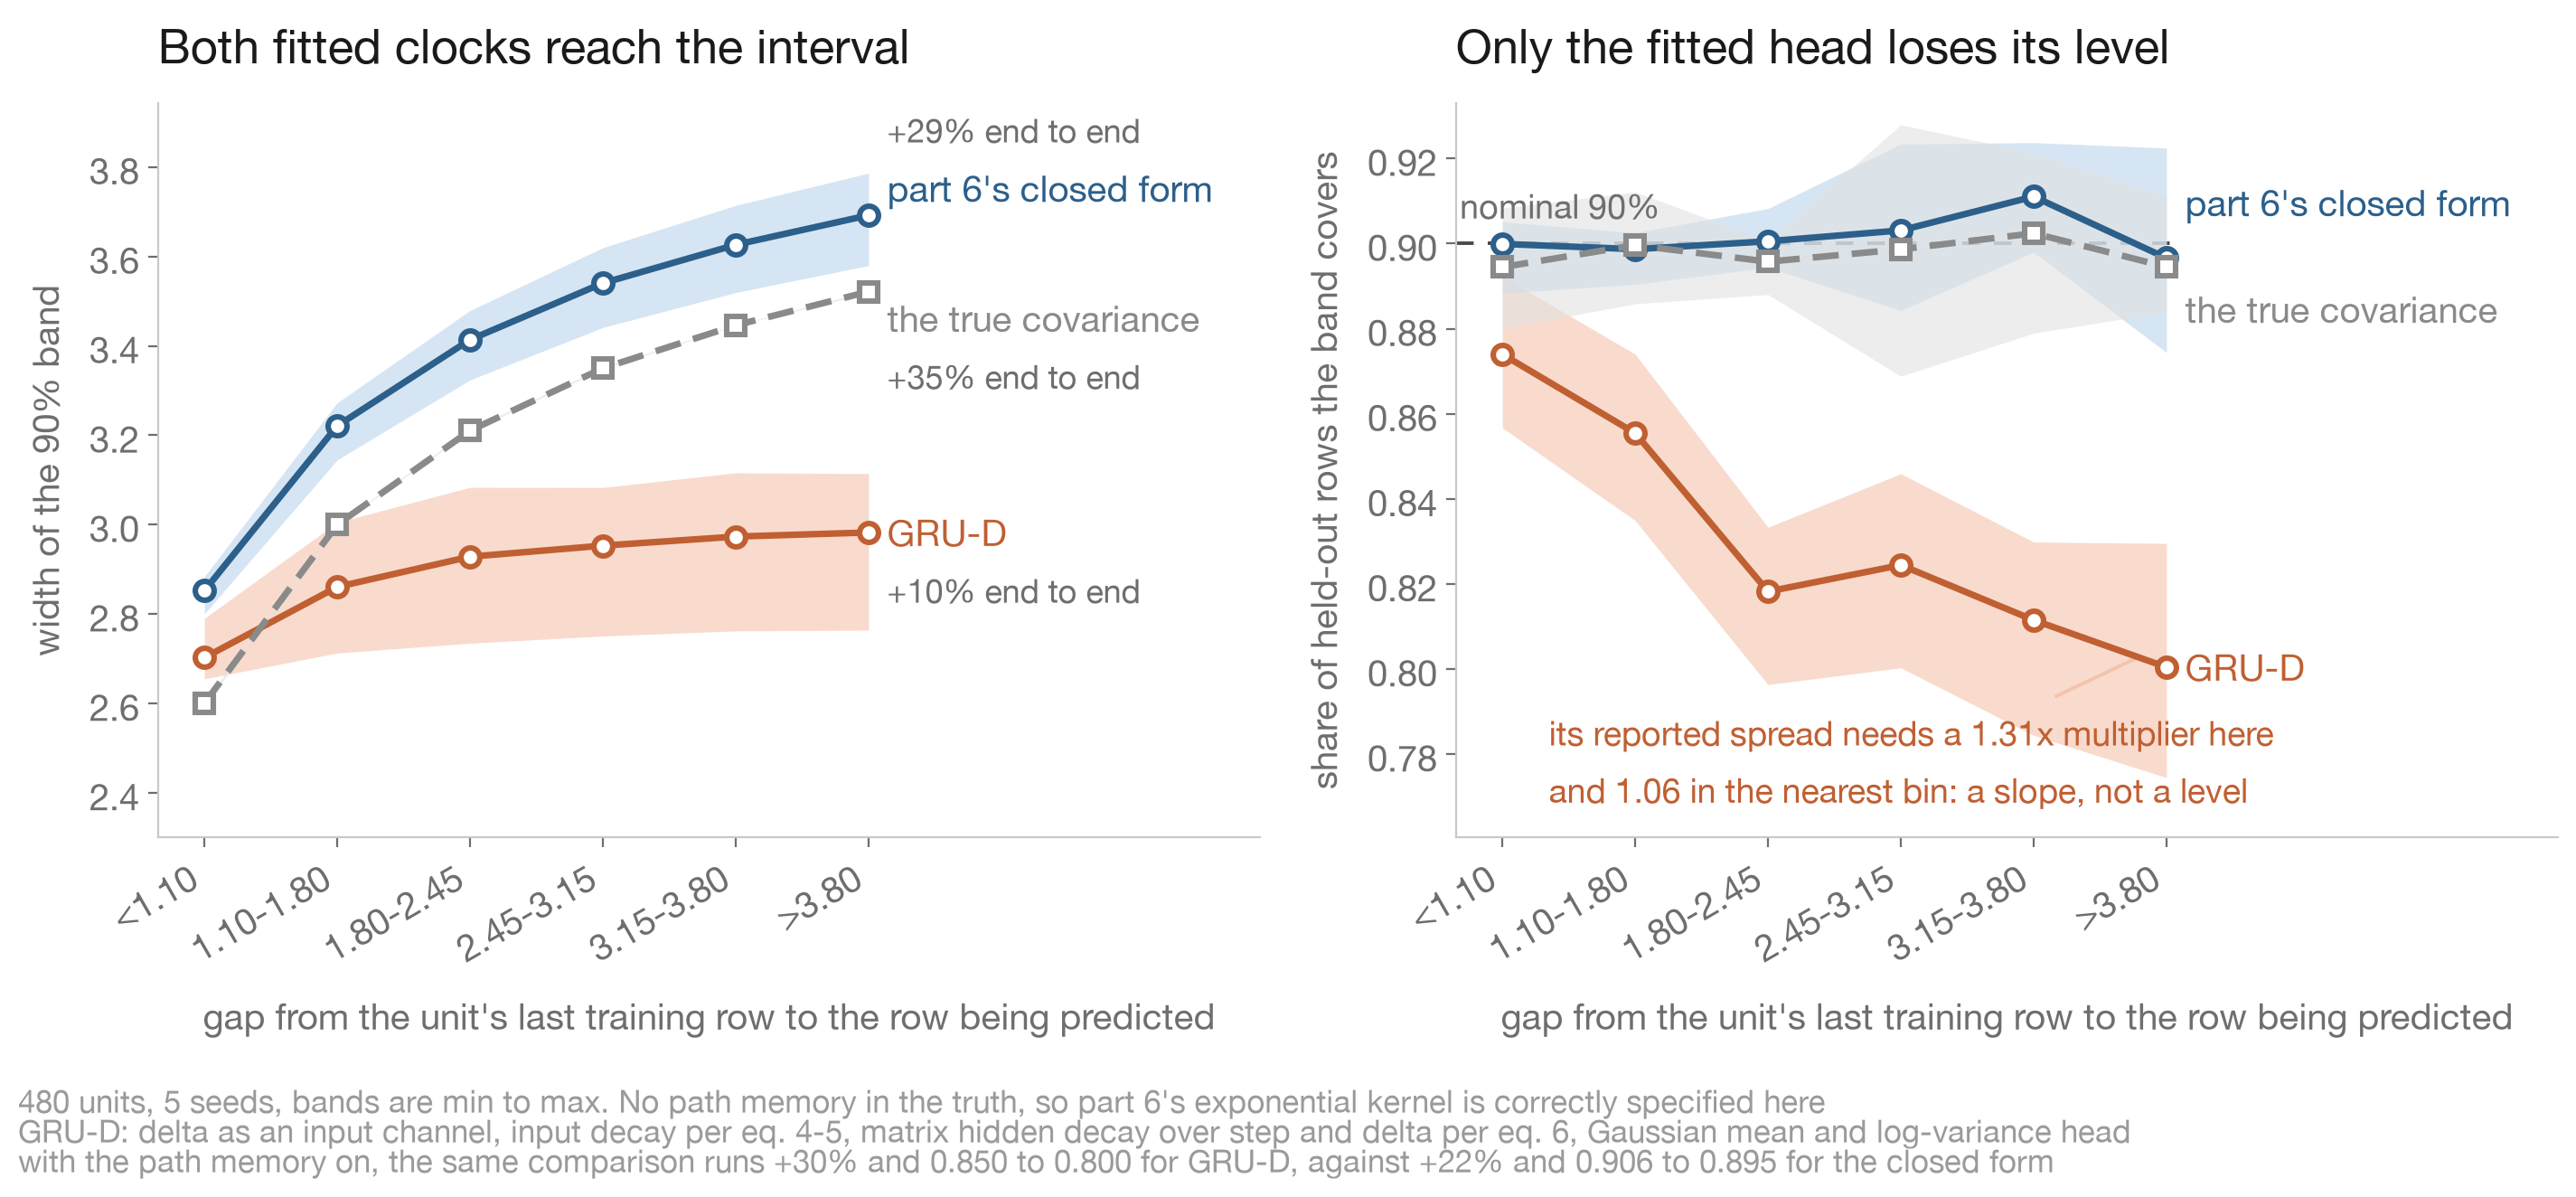

In [31]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, BLUE_F = "#2C5F8A", "#B9D5EC"
CORAL_E, CORAL_F = "#C05F32", "#F4C3AC"
GREY_E, GREY_F = "#8a8a8a", "#E2E2E2"
INK, MUTED, FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"
SERIES = [("+ GRU-D", CORAL_E, CORAL_F, "o", "-", "GRU-D"),
          ("+ kernel", BLUE_E, BLUE_F, "o", "-", "part 6's closed form"),
          ("oracle", GREY_E, GREY_F, "s", (0, (4, 2)), "the true covariance")]
x = np.arange(len(GAPL))
F = A[(A.ng == BIG) & (A.c == 0.0)]
ON = A[(A.ng == BIG) & (A.c == CVAL)].groupby("arm")

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.6), dpi=200)
fig.patch.set_facecolor("white")


def draw(ax, cols, dy):
    for arm, ec, fc, mk, ls, lab in SERIES:
        d = F[F.arm == arm][cols]
        ax.fill_between(x, d.min().values, d.max().values, color=fc, alpha=0.6, lw=0, zorder=2)
        ax.plot(x, d.mean().values, color=ec, lw=2.6, ls=ls, marker=mk, ms=7.5, mfc="white",
                mew=2.2, zorder=4)
        ax.text(x[-1] + 0.14, d.mean().values[-1] + dy[arm], lab, fontsize=14.5, color=ec,
                va="center")
    ax.set_xticks(x)
    ax.set_xticklabels(GAPL, rotation=30, ha="right")
    ax.set_xlim(-0.35, len(GAPL) + 1.95)
    ax.set_xlabel("gap from the unit's last training row to the row being predicted",
                  fontsize=14.5, color=MUTED, labelpad=10)


# left: the width of the band against the gap
ax = axes[0]
DRAWN = [a for a, *_ in SERIES]
w = F.groupby("arm")[WCOL].mean()
lo, hi = w[WCOL[0]], w[WCOL[-1]]
draw(ax, WCOL, {"+ GRU-D": 0.0, "+ kernel": 0.06, "oracle": -0.06})
for arm, dy in (("+ GRU-D", -0.13), ("+ kernel", 0.19), ("oracle", -0.19)):
    ax.text(x[-1] + 0.14, hi[arm] + dy, f"{hi[arm]/lo[arm] - 1:+.0%} end to end", fontsize=13,
            color=MUTED, va="center")
ax.set_ylim(lo[DRAWN].min() - 0.30, hi[DRAWN].max() + 0.25)
ax.set_ylabel("width of the 90% band", fontsize=14.5, color=MUTED, labelpad=9)
ax.set_title("Both fitted clocks reach the interval", fontsize=19, color=INK, pad=16, loc="left")

# right: whether the band holds its nominal level as the gap grows
ax = axes[1]
cv = F.groupby("arm")[CCOL].mean()
draw(ax, CCOL, {"+ GRU-D": 0.0, "+ kernel": 0.013, "oracle": -0.010})
ax.plot([-0.35, x[-1] + 0.06], [0.90]*2, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.text(-0.32, 0.9042, "nominal 90%", fontsize=13.5, color=MUTED, va="bottom")
far = cv.loc["+ GRU-D", CCOL[-1]]
need = HB[(HB.ng == BIG) & (HB.c == 0.0) & (HB.rows == "target")][GAPL].mean()
ax.set_ylim(far - 0.040, max(0.925, F[F.arm.isin(DRAWN)][CCOL].max().max() + 0.005))
ax.annotate(f"its reported spread needs a {need.iloc[-1]:.2f}x multiplier here\nand "
            f"{need.iloc[0]:.2f} in the nearest bin: a slope, not a level",
            xy=(x[-1] - 0.1, far + 0.004), xytext=(0.35, far - 0.023), fontsize=13.5,
            color=CORAL_E, va="center", ha="left", linespacing=1.45,
            arrowprops=dict(arrowstyle="-", color=CORAL_F, lw=1.4, shrinkA=6, shrinkB=6))
ax.set_ylabel("share of held-out rows the band covers", fontsize=14.5, color=MUTED, labelpad=9)
ax.set_title("Only the fitted head loses its level", fontsize=19, color=INK, pad=16, loc="left")

for ax in axes:
    ax.tick_params(labelsize=14.5, colors=MUTED, length=4)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c9c9c9")

wo, co = ON[WCOL].mean(), ON[CCOL].mean()
fig.text(0.008, 0.060, f"{BIG} units, {NSEED} seeds, bands are min to max. No path memory in the "
         "truth, so part 6's exponential kernel is correctly specified here", fontsize=12.5,
         color=FAINT, ha="left")
fig.text(0.008, 0.035, "GRU-D: delta as an input channel, input decay per eq. 4-5, matrix hidden "
         "decay over step and delta per eq. 6, Gaussian mean and log-variance head", fontsize=12.5,
         color=FAINT, ha="left")
fig.text(0.008, 0.010, "with the path memory on, the same comparison runs "
         f"{wo.loc['+ GRU-D'].iloc[-1]/wo.loc['+ GRU-D'].iloc[0] - 1:+.0%} and "
         f"{co.loc['+ GRU-D'].iloc[0]:.3f} to {co.loc['+ GRU-D'].iloc[-1]:.3f} for GRU-D, against "
         f"{wo.loc['+ kernel'].iloc[-1]/wo.loc['+ kernel'].iloc[0] - 1:+.0%} and "
         f"{co.loc['+ kernel'].iloc[0]:.3f} to {co.loc['+ kernel'].iloc[-1]:.3f} for the closed "
         "form", fontsize=12.5, color=FAINT, ha="left")
fig.tight_layout(rect=[0, 0.100, 1, 1.0])
fig.savefig("panel_sequence_models.png", facecolor="white")
plt.show()

## What this notebook measured

The decay is a kernel. GRU-D's gate and the conditional mean of part 6's exponential covariance are
the same expression, so the mechanism is a covariance function restricted to one family and fitted
by gradient descent. Rubanova et al. say the same from the other direction, that a decayed hidden
state solves a linear ODE. That is where the family resemblance stops: mTAND attends over an
embedded time axis, latent ODEs relax along a learned vector field, and the continuous recurrent
unit's Kalman filter over a linear latent SDE is `corCAR1` only if you reduce its latent state to a
scalar.

A Gaussian head on that mechanism does give you an interval, and it is not a flat one. Its width
opens by 10% from the shortest gap bin to the longest with no path memory in the truth and by 30%
with it, where the closed form opens by 29% and 22% and the true covariance by 35%. So the decay
reaches the second moment. What fails is the level, and it fails in the gap: coverage drops from the first bin
to the last on every seed, while both closed-form arms hold their nominal level across the same
bins.

Where that failure lives needs the by-gap table. In aggregate the head needs a multiplier within a few
per cent of one on the training rows of units it held out and a fifth more on the target rows, which
invites the story that it is calibrated for rows it has seen. The by-gap table does not support that
story. On the target rows the multiplier rises with the gap, from 1.06 in the nearest bin to 1.31
in the farthest, while the training rows sit almost entirely in the short bins where it is near
one. Putting the target rows' multipliers on the training rows' gap mix accounts for 74% of the
aggregate contrast with no path memory and 36% with it, so the head is miscalibrated both because
a row is far and because it is unseen, in a share that depends on the truth. Either way the rescaled
arm in the tables barely moves: a scalar cannot straighten a slope.

The kernel arm's variance is not fitted at any gap. It is a consequence of the covariance function,
so it extrapolates by construction, and the misspecification cell shows how far that carries: with
the unit effect drawn from a Matern 3/2 or from two exponentials an order of magnitude apart, the
exponential fit reports a range that is not the truth by a wide margin and its coverage still holds
level across the bins.

That interval does not widen without limit. It settles at the marginal sd, `sqrt(var_u + s2)`, and
gets 99% of the way there by about 2.2 ranges past the unit's last row, under the true covariance
and under the fitted one alike. Read as a multiplier with a band that resamples whole units, the
kernel's need stays within a few per cent of one in every gap bin while GRU-D's climbs, and
resampling units rather than rows widens those bands by only 1.1 to 1.2 times, because each unit
contributes few target rows.

Fitting the covariance and the trees jointly, in GPBoost, rather than in two stages, leaves the mean
where it was, within 0.003 of RMSE, and takes the interval apart: the noise variance goes to zero,
the trees absorb it, and the joint interval covers 0.747 with no path memory and 0.782 with it,
worst in the nearest bin. Its sd runs 0.55 to 0.79 of the two-stage one by bin. The two-stage fit's
residuals are out of fold, which is what keeps its noise variance honest.

Two alternative explanations are ruled out rather than argued away. Undertraining: the validation
loss is at its best by step 75 of three thousand and more than a nat worse at the ceiling, so the
scored net is the best one this architecture reaches here. And crediting the wrong mechanism: GRU-D's own
input decay is `exp(-max(0, W d + b))`, and the fitted `W` lands in the flat part of that `max` in
8 of the 20 fits, leaving the gate at exactly 1. Where that happens the published input decay
contributed nothing and the hidden-state decay carried the gap alone. Which fits it happens in
depends on the initialisation, not on the data alone, which is why the fits below vary their
initialisation with the panel's seed rather than starting every one from the same weights.

None of this is a statement about model families. The continuous recurrent unit carries both a
propagated state covariance and an input-dependent observation noise; GRU-ODE-Bayes propagates a
state covariance under a Gaussian output head. And the Neural CDE paper says in as many words that
its models give no measure of uncertainty. The claim is about the
mechanism and about what a fitted head does with it: a gate is a conditional mean, and a conditional
mean is half of a predictive distribution.

On the mean, which arm wins is decided by what the truth is made of, and the arms trade places.
Where the truth is a Gauss-Markov unit effect, part 6's two stages close 75% of the distance to the
oracle and GRU-D 54%, while the guessed columns are worse than not having them at all. Where the
truth also contains a functional of the covariate path, which no covariance over observation times
can express, GRU-D closes 23% against the covariance route's 13%, the guessed columns 36%, and the
columns with the covariance on their residuals 50%, which is the best arm here on both the mean and
the interval. In RMSE that is 1.056 for GRU-D against 1.021 with no path memory, and 1.531 against
1.602 with it.

Guessing that path memory is forgiving in both of its parameters. A single exponential average has
to be within a factor of a few of the true rate, but two columns straddling it recover as much as
one column at the true rate, because the trees interpolate between them, and replacing the
nonlinearity the truth averages with a generic quadratic basis costs almost nothing. The scan is
asymmetric: guessing too slow is fatal and guessing too fast is nearly free, so guess high.

Two things worth carrying forward. The two-stage covariance fit is stable down to thirty units,
where it still recovers the unit-effect variance and reports a shortened range, so the failure mode
on a small panel is a biased range rather than a divergence. And when the truth contains path
memory, that same fit attributes it to the unit effect: the variance roughly doubles and the range
comes back at less than half the truth. The interval stays calibrated, so nothing in the coverage
table gives the misattribution away. Part 6's variogram is where to look.

Where this sits: GRU-D is Che et al. (2018), mTAND is Shukla and Marlin (2021), HeTVAE, which
reports constant uncertainty for that family, is Shukla and Marlin (2022), the latent ODE is
Rubanova, Chen and Duvenaud (2019), Neural CDEs are Kidger et al. (2020), GRU-ODE-Bayes is
De Brouwer et al. (2019), and the continuous recurrent unit is Schirmer et al. (2022). The
exponential kernel over observation time is `corCAR1` in the mixed-model literature and the
Ornstein-Uhlenbeck process everywhere else.